In [2]:
import pandas as pd
import os

# Set file paths
input_path = 'data/GiveMeSomeCredit/cs-training.csv'  # Raw GMSC Data
output_dir = 'preprocess/raw_GMSC_data_analysis'
os.makedirs(output_dir, exist_ok=True)

# Sample and read first 10,000 rows for field exploration
sample_df = pd.read_csv(input_path, nrows=10000, low_memory=False)

# Build a field analysis summary
summary = pd.DataFrame({
    'field_name': sample_df.columns,
    'data_type': sample_df.dtypes.astype(str),
    'missing_rate': sample_df.isnull().mean().round(4),
    'num_unique_values': sample_df.nunique(),
    'sample_value': sample_df.iloc[0].astype(str).values
})

# Save summary as CSV
output_file = os.path.join(output_dir, 'field_structure_analysis.csv')
summary.to_csv(output_file, index=False, encoding='utf-8-sig')

print("Field structure analysis saved to:", output_file)


Field structure analysis saved to: preprocess/raw_GMSC_data_analysis\field_structure_analysis.csv


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os


file_path = 'data/GiveMeSomeCredit/cs-training.csv'
output_dir = 'preprocess/raw_GMSC_data_analysis'
os.makedirs(output_dir, exist_ok=True)


df = pd.read_csv(file_path, usecols=['SeriousDlqin2yrs'])


counts = df['SeriousDlqin2yrs'].value_counts().sort_index()
total = counts.sum()


status_df = pd.DataFrame({
    'SeriousDlqin2yrs': counts.index.astype(str),
    'count': counts.values
})


csv_path = os.path.join(output_dir, 'GMSC_SeriousDlqin2yrs_counts.csv')
status_df.to_csv(csv_path, index=False)


plt.figure(figsize=(6, 4))
bars = plt.bar(status_df['SeriousDlqin2yrs'], status_df['count'])
plt.xlabel('SeriousDlqin2yrs (0 = No default, 1 = Default)')
plt.ylabel('Count')
plt.title('GMSC Loan Default Distribution')
plt.ticklabel_format(style='plain', axis='y')  # Show plain numbers

# Add labels: absolute/percentage
for bar, value in zip(bars, status_df['count']):
    percentage = value / total * 100
    plt.text(bar.get_x() + bar.get_width() / 2,
             value + max(status_df['count']) * 0.01,
             f"{value:,}  /  {percentage:.1f}%",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Save figure
fig_path = os.path.join(output_dir, 'GMSC_default_distribution.png')
plt.savefig(fig_path, dpi=300)
plt.close()

print(f"CSV saved to: {csv_path}")
print(f"Figure saved to: {fig_path}")


CSV saved to: preprocess/raw_GMSC_data_analysis\GMSC_SeriousDlqin2yrs_counts.csv
Figure saved to: preprocess/raw_GMSC_data_analysis\GMSC_default_distribution.png


In [1]:
import pandas as pd

file_path = 'data/archive/accepted_2007_to_2018Q4.csv'

# Read only the first 5 lines
df_head = pd.read_csv(file_path, nrows=5, low_memory=False)
print("Total columns:", df_head.shape[1])
print("All column names are as follows：")
print(df_head.columns.tolist())


Total columns: 151
All column names are as follows：
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_jo

In [6]:
import pandas as pd
import os

# Set file paths
input_path = 'data/archive/accepted_2007_to_2018Q4.csv'  # Raw Lending Club Data
output_dir = 'preprocess/raw_data_analysis'
os.makedirs(output_dir, exist_ok=True)

# Sample and read first 10,000 rows for field exploration
sample_df = pd.read_csv(input_path, nrows=10000, low_memory=False)

# Build a field analysis summary
summary = pd.DataFrame({
    'field_name': sample_df.columns,
    'data_type': sample_df.dtypes.astype(str),
    'missing_rate': sample_df.isnull().mean().round(4),
    'num_unique_values': sample_df.nunique(),
    'sample_value': sample_df.iloc[0].astype(str).values
})

# Save summary as CSV
output_file = os.path.join(output_dir, 'field_structure_analysis.csv')
summary.to_csv(output_file, index=False, encoding='utf-8-sig')

print("Field structure analysis saved to:", output_file)


Field structure analysis saved to: preprocess/raw_data_analysis\field_structure_analysis.csv


In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt


file_path = 'data/archive/accepted_2007_to_2018Q4.csv'
output_dir = 'preprocess/raw_data_analysis'
os.makedirs(output_dir, exist_ok=True)


year_counts = {}


chunk_size = 500000
for chunk in pd.read_csv(file_path, usecols=['issue_d'], chunksize=chunk_size, low_memory=False):
    # Drop missing values in issue_d
    chunk = chunk.dropna(subset=['issue_d'])
    # Convert issue_d to datetime format
    chunk['year'] = pd.to_datetime(chunk['issue_d'], format='%b-%Y').dt.year
    # Count number of records per year in this chunk
    chunk_counts = chunk['year'].value_counts().to_dict()
    # Aggregate counts into year_counts
    for year, count in chunk_counts.items():
        year_counts[year] = year_counts.get(year, 0) + count


year_df = pd.DataFrame(sorted(year_counts.items()), columns=['Year', 'Count'])


plt.figure(figsize=(10, 6))
bars = plt.bar(year_df['Year'].astype(str), year_df['Count'])
plt.xlabel('Year')
plt.ylabel('Number of Loans')
plt.title('Loan Distribution by Year (Lending Club)')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:,}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()


plot_path = os.path.join(output_dir, 'loan_distribution_by_year.png')
plt.savefig(plot_path, dpi=300)
plt.close()


csv_path = os.path.join(output_dir, 'loan_distribution_by_year.csv')
year_df.to_csv(csv_path, index=False)

print(f"Yearly loan distribution saved to:\n- {plot_path}\n- {csv_path}")


Yearly loan distribution saved to:
- preprocess/raw_data_analysis\loan_distribution_by_year.png
- preprocess/raw_data_analysis\loan_distribution_by_year.csv


In [18]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import os

file_path = 'data/archive/accepted_2007_to_2018Q4.csv'
output_dir = 'preprocess/raw_data_analysis'
os.makedirs(output_dir, exist_ok=True)

# Initialize counter
loan_status_counter = Counter()

# Read loan_status in chunks
chunk_size = 500_000
for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, usecols=['loan_status'], low_memory=False)):
    print(f"Analyzing chunk {i + 1}...")
    loan_status_counter.update(chunk['loan_status'].dropna())

# Convert Counter to DataFrame
status_df = pd.DataFrame(loan_status_counter.items(), columns=['loan_status', 'count'])
status_df = status_df.sort_values(by='count', ascending=False)

# Save CSV
csv_path = os.path.join(output_dir, 'loan_status_counts.csv')
status_df.to_csv(csv_path, index=False)

# Plot top 30 loan_status
top30 = status_df.head(30)
total = top30['count'].sum()  # total count of top30

plt.figure(figsize=(12, 6))
bars = plt.barh(top30['loan_status'], top30['count'])
plt.xlabel('Count')
plt.ylabel('Loan Status')
plt.title('Top 30 Loan Status Frequencies')
plt.gca().invert_yaxis()  # Highest count at the top
plt.ticklabel_format(style='plain', axis='x')  # Show plain numbers on x-axis

# Add value and percentage labels
for bar, value in zip(bars, top30['count']):
    percentage = value / total * 100
    label = f"{value:,}  /  {percentage:.1f}%"  # e.g., 10,000/50.0%
    plt.text(value + max(top30['count']) * 0.01,  # offset to the right
             bar.get_y() + bar.get_height() / 2,
             label, va='center', fontsize=9)

plt.tight_layout()

# Save figure
fig_path = os.path.join(output_dir, 'loan_status_top30.png')
plt.savefig(fig_path, dpi=300)
plt.close()



print(f"\nCSV saved to: {csv_path}")
print(f"Figure saved to: {fig_path}")



Analyzing chunk 1...
Analyzing chunk 2...
Analyzing chunk 3...
Analyzing chunk 4...
Analyzing chunk 5...

CSV saved to: preprocess/raw_data_analysis\loan_status_counts.csv
Figure saved to: preprocess/raw_data_analysis\loan_status_top30.png


In [41]:
import os
import pandas as pd

file_path = 'data/archive/accepted_2007_to_2018Q4.csv'
output_dir = 'preprocess/raw_LC_data/raw'
os.makedirs(output_dir, exist_ok=True)

# Columns to keep
selected_columns = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose',
    'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'application_type', 'earliest_cr_line', 'mths_since_last_delinq',
    'loan_status', 'issue_d'
]

df = pd.read_csv(file_path, usecols=selected_columns, low_memory=False)

save_path = os.path.join(output_dir, 'LC_selected_features.csv')
df.to_csv(save_path, index=False)

print(f"Filtered Lending Club dataset saved to: {save_path}")


Filtered Lending Club dataset saved to: preprocess/raw_LC_data/raw\LC_selected_features.csv


In [42]:
import pandas as pd
import os

# Set file paths
input_path = 'preprocess/raw_LC_data/raw/LC_selected_features.csv'
output_dir = 'preprocess/raw_data_analysis/selected'
os.makedirs(output_dir, exist_ok=True)

# Sample and read first 10,000 rows for field exploration
sample_df = pd.read_csv(input_path, nrows=10000, low_memory=False)

# Build a field analysis summary
summary = pd.DataFrame({
    'field_name': sample_df.columns,
    'data_type': sample_df.dtypes.astype(str),
    'missing_rate': sample_df.isnull().mean().round(4),
    'num_unique_values': sample_df.nunique(),
    'sample_value': sample_df.iloc[0].astype(str).values
})

# Save summary as CSV
output_file = os.path.join(output_dir, 'field_structure_analysis.csv')
summary.to_csv(output_file, index=False, encoding='utf-8-sig')

print("Field structure analysis saved to:", output_file)

Field structure analysis saved to: preprocess/raw_data_analysis/selected\field_structure_analysis.csv


In [43]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


file_path = 'preprocess/raw_LC_data/raw/LC_selected_features.csv'
output_dir = 'preprocess/raw_data_analysis/variable_distribution'
os.makedirs(output_dir, exist_ok=True)


print("Loading Lending Club dataset...")
df = pd.read_csv(file_path, low_memory=False)

# ================================
# Detect variable types
# ================================
numerical_cols = [col for col in df.columns if df[col].dtype == 'float64']
categorical_cols = [col for col in df.columns if col not in numerical_cols]


cat_dir = os.path.join(output_dir, 'categorical')
os.makedirs(cat_dir, exist_ok=True)

for col in categorical_cols:
    freq = df[col].value_counts(dropna=False)
    freq_path = os.path.join(cat_dir, f'{col}_frequency.csv')
    freq.to_csv(freq_path, header=['count'])

    plt.figure(figsize=(10, 5))
    freq.head(30).plot(kind='bar')
    plt.title(f'{col} - Top 30 Category Frequency')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(cat_dir, f'{col}_bar.png'), dpi=300)
    plt.close()


num_dir = os.path.join(output_dir, 'numerical')
os.makedirs(num_dir, exist_ok=True)

desc = df[numerical_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc['IQR'] = desc['75%'] - desc['25%']
desc['Lower_bound'] = desc['25%'] - 1.5 * desc['IQR']
desc['Upper_bound'] = desc['75%'] + 1.5 * desc['IQR']
outlier_flags = {}

for col in numerical_cols:
    lower, upper = desc.loc[col, 'Lower_bound'], desc.loc[col, 'Upper_bound']
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_flags[col] = len(outliers)

# Combine outlier info
desc['outlier_count'] = pd.Series(outlier_flags)
desc.to_csv(os.path.join(num_dir, 'numerical_descriptive_LC.csv'))


print(f"Processed Lending Club variables: categorical({len(categorical_cols)}), numerical({len(numerical_cols)})")


Loading Lending Club dataset...
Processed Lending Club variables: categorical(13), numerical(15)


In [20]:
# ================================
# Paths
# ================================
file_path = 'data/GiveMeSomeCredit/cs-training.csv'
output_dir = 'preprocess/raw_GMSC_data_analysis/variable_distribution'
os.makedirs(output_dir, exist_ok=True)

# ================================
# Load dataset
# ================================
print("Loading GMSC dataset...")
df = pd.read_csv(file_path)

# ================================
# Detect variable types
# ================================
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' or df[col].nunique() < 50]
numerical_cols = [col for col in df.columns if col not in categorical_cols]


cat_dir = os.path.join(output_dir, 'categorical')
os.makedirs(cat_dir, exist_ok=True)

for col in categorical_cols:
    freq = df[col].value_counts(dropna=False)
    freq_path = os.path.join(cat_dir, f'{col}_frequency.csv')
    freq.to_csv(freq_path, header=['count'])

    plt.figure(figsize=(8, 4))
    freq.head(30).plot(kind='bar')
    plt.title(f'{col} - Top 30 Category Frequency')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(cat_dir, f'{col}_bar.png'), dpi=300)
    plt.close()


num_dir = os.path.join(output_dir, 'numerical')
os.makedirs(num_dir, exist_ok=True)

desc = df[numerical_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc['IQR'] = desc['75%'] - desc['25%']
desc['Lower_bound'] = desc['25%'] - 1.5 * desc['IQR']
desc['Upper_bound'] = desc['75%'] + 1.5 * desc['IQR']
outlier_flags = {}

for col in numerical_cols:
    lower, upper = desc.loc[col, 'Lower_bound'], desc.loc[col, 'Upper_bound']
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_flags[col] = len(outliers)

# Combine outlier info
desc['outlier_count'] = pd.Series(outlier_flags)
desc.to_csv(os.path.join(num_dir, 'numerical_descriptive_GMSC.csv'))


print(f"Processed GMSC variables: categorical({len(categorical_cols)}), numerical({len(numerical_cols)})")


Loading GMSC dataset...
Processed GMSC variables: categorical(6), numerical(6)


In [48]:
import pandas as pd
import os
import matplotlib.pyplot as plt

file_path = 'preprocess/raw_LC_data/raw/LC_selected_features.csv'
output_dir = 'preprocess/raw_data_analysis/missing_rate'
os.makedirs(output_dir, exist_ok=True)

# === Step 1: Calculate missing counts in chunks ===
col_missing = None
total_rows = 0
chunk_size = 500000

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, low_memory=False)):
    if col_missing is None:
        col_missing = pd.Series(0, index=chunk.columns)
    col_missing += chunk.isna().sum()
    total_rows += len(chunk)
    print(f"Processed chunk {i+1}")

# === Step 2: Compute missing rates ===
missing_rate = (col_missing / total_rows * 100).round(2)
missing_df = pd.DataFrame({
    'column': col_missing.index,
    'missing_count': col_missing.values,
    'missing_rate(%)': missing_rate.values
})
missing_df = missing_df[missing_df['missing_rate(%)'] > 0].sort_values(by='missing_rate(%)', ascending=False)

# === Step 3: Save CSV ===
csv_path = os.path.join(output_dir, 'LC_missing_values.csv')
missing_df.to_csv(csv_path, index=False)

# === Step 4: Plot missing values ===
plt.figure(figsize=(12, 6))
bars = plt.barh(missing_df['column'], missing_df['missing_rate(%)'])
plt.xlabel('Missing Rate (%)')
plt.title('Lending Club - Missing Value Rates')
plt.gca().invert_yaxis()

# Add value labels
for bar, count, rate in zip(bars, missing_df['missing_count'], missing_df['missing_rate(%)']):
    plt.text(rate + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{count:,} / {rate:.2f}%", va='center', fontsize=9)

plt.tight_layout()

# Save figure
fig_path = os.path.join(output_dir, 'LC_missing_values.png')
plt.savefig(fig_path, dpi=300)
plt.close()

print(f"Missing value report saved to:\n- {csv_path}\n- {fig_path}")


Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Missing value report saved to:
- preprocess/raw_data_analysis/missing_rate\LC_missing_values.csv
- preprocess/raw_data_analysis/missing_rate\LC_missing_values.png


In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt

file_path = 'data/GiveMeSomeCredit/cs-training.csv'
output_dir = 'preprocess/raw_GMSC_data_analysis/missing_rate'
os.makedirs(output_dir, exist_ok=True)

# === Step 1: Read dataset and calculate missing ===
df = pd.read_csv(file_path)
missing_count = df.isna().sum()
missing_rate = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'column': df.columns,
    'missing_count': missing_count.values,
    'missing_rate(%)': missing_rate.values
})
missing_df = missing_df[missing_df['missing_rate(%)'] > 0].sort_values(by='missing_rate(%)', ascending=False)

# === Step 2: Save CSV ===
csv_path = os.path.join(output_dir, 'GMSC_missing_values.csv')
missing_df.to_csv(csv_path, index=False)

# === Step 3: Plot missing values ===
plt.figure(figsize=(10, 5))
bars = plt.barh(missing_df['column'], missing_df['missing_rate(%)'])
plt.xlabel('Missing Rate (%)')
plt.title('GMSC - Missing Value Rates')
plt.gca().invert_yaxis()

# Add value labels
for bar, count, rate in zip(bars, missing_df['missing_count'], missing_df['missing_rate(%)']):
    plt.text(rate + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{count:,}/{rate:.2f}%", va='center', fontsize=9)

plt.tight_layout()

# Save figure
fig_path = os.path.join(output_dir, 'GMSC_missing_values.png')
plt.savefig(fig_path, dpi=300)
plt.close()

print(f"Missing value report saved to:\n- {csv_path}\n- {fig_path}")


Missing value report saved to:
- preprocess/raw_GMSC_data_analysis/missing_rate\GMSC_missing_values.csv
- preprocess/raw_GMSC_data_analysis/missing_rate\GMSC_missing_values.png


In [49]:
import pandas as pd
import os

file_path = 'preprocess/raw_LC_data/raw/LC_selected_features.csv'
output_dir = 'preprocess/raw_LC_data/filled'
os.makedirs(output_dir, exist_ok=True)

# Read in chunks to handle large file
chunk_size = 500000
save_path = os.path.join(output_dir, 'LC_filled.csv')

# Remove old file
if os.path.exists(save_path):
    os.remove(save_path)

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, low_memory=False)):
    # mths_since_last_delinq → fill -1 & missing flag
    chunk['mths_missing_flag'] = chunk['mths_since_last_delinq'].isna().astype(int)
    chunk['mths_since_last_delinq'] = chunk['mths_since_last_delinq'].fillna(-1)

    # emp_length → fill with 'Unknown'
    if 'emp_length' in chunk.columns:
        chunk['emp_length'] = chunk['emp_length'].fillna('Unknown')

    # dti, revol_util → fill with median (chunk-wise OK since low missing)
    for col in ['dti', 'revol_util']:
        if col in chunk.columns:
            median_val = chunk[col].median()
            chunk[col] = chunk[col].fillna(median_val)

    # Append processed chunk
    chunk.to_csv(save_path, mode='a', index=False, header=(i == 0))
    print(f"Processed chunk {i+1}")

print(f"Lending Club filled dataset saved to: {save_path}")

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Lending Club filled dataset saved to: preprocess/raw_LC_data/filled\LC_filled.csv


In [18]:
file_path = 'data/GiveMeSomeCredit/cs-training.csv'
output_dir = 'preprocess/raw_GMSC_data/filled'
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(file_path)

# MonthlyIncome → fill with median & missing flag
df['MonthlyIncome_missing_flag'] = df['MonthlyIncome'].isna().astype(int)
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# NumberOfDependents → fill with median
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

# Save
save_path = os.path.join(output_dir, 'GMSC_filled.csv')
df.to_csv(save_path, index=False)

print(f"GMSC filled dataset saved to: {save_path}")


GMSC filled dataset saved to: preprocess/raw_GMSC_data/filled\GMSC_filled.csv


In [50]:
import pandas as pd
import os


file_path = 'preprocess/raw_LC_data/raw/LC_selected_features.csv'
output_dir = 'preprocess/data_features/proxy_features'
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'proxy_raw.csv')


proxy_cols = ['home_ownership', 'zip_code', 'addr_state']
df = pd.read_csv(file_path, usecols=proxy_cols, low_memory=False)

df.to_csv(save_path, index=False)

print(f"Proxy features saved to: {save_path}")


Proxy features saved to: preprocess/data_features/proxy_features\proxy_raw.csv


In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'preprocess/raw_LC_data/raw/LC_selected_features.csv'
output_dir = 'preprocess/data_features/proxy_features/analysis'
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(file_path, low_memory=False)

# 1. Describe group distribution for proxy variables
proxy_vars = ['home_ownership', 'zip_code', 'addr_state']

for var in proxy_vars:
    counts = df[var].value_counts().reset_index()
    counts.columns = [var, 'count']
    counts['percentage'] = counts['count'] / counts['count'].sum() * 100

    # Save distribution CSV
    counts_csv = os.path.join(output_dir, f'{var}_distribution.csv')
    counts.to_csv(counts_csv, index=False)

    # Plot distribution (top 30 for zip/state to avoid overcrowding)
    plt.figure(figsize=(10, 5))
    if var == 'home_ownership':
        order = counts[var]
    else:
        order = counts[var].head(30)
        counts = counts.head(30)

    bars = plt.bar(order, counts['count'])
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.title(f'{var} Distribution')
    plt.xticks(rotation=45)

    # Only annotate top 10 to avoid clutter
    for i, (bar, c, p) in enumerate(zip(bars, counts['count'], counts['percentage'])):
        if i < 10:
            # annotate only top 10
            plt.text(bar.get_x() + bar.get_width()/2, c + max(counts['count']) * 0.01,
                     f"{c:,}/{p:.1f}%", ha='center', va='bottom', fontsize=8, rotation=45)


    plt.tight_layout()
    fig_path = os.path.join(output_dir, f'{var}_distribution.png')
    plt.savefig(fig_path, dpi=300)
    plt.close()


# 2. Check significant differences between groups (Income and FICO score)
# Use home_ownership and addr_state as grouping factors
# Numerical variables to compare
num_vars = ['annual_inc', 'fico_range_low', 'fico_range_high']

from scipy.stats import f_oneway, kruskal

results = []

for group_var in ['home_ownership', 'addr_state']:
    for num in num_vars:
        # Drop missing
        temp = df[[group_var, num]].dropna()
        # Create groups
        groups = [grp[num].values for name, grp in temp.groupby(group_var) if len(grp) > 1]
        if len(groups) > 1:
            # Use Kruskal-Wallis (non-parametric, robust to non-normality)
            stat, p = kruskal(*groups)
            results.append({
                'group_var': group_var,
                'num_var': num,
                'kruskal_H': stat,
                'p_value': p,
                'significant': 'Yes' if p < 0.05 else 'No'
            })

# Save test results
results_df = pd.DataFrame(results)
results_csv = os.path.join(output_dir, 'group_difference_tests.csv')
results_df.to_csv(results_csv, index=False)

print(f"Proxy variable distributions, group difference tests, and plots saved to: {output_dir}")


Proxy variable distributions, group difference tests, and plots saved to: preprocess/data_features/proxy_features/analysis


In [1]:
import os
import pandas as pd

file_path = 'preprocess/raw_LC_data/raw/LC_selected_features.csv'
output_dir = 'preprocess/data_features/proxy_features'
os.makedirs(output_dir, exist_ok=True)


df = pd.read_csv(file_path, low_memory=False)


# 1. zip_code → Top 10 + OTHER
zip_counts = df['zip_code'].value_counts()
top10_zip = set(zip_counts.head(10).index)
df['zip_group'] = df['zip_code'].apply(lambda x: x if x in top10_zip else 'OTHER')

# 2. addr_state → merge small groups (<1%) to OTHER
state_counts = df['addr_state'].value_counts(normalize=True)
large_states = set(state_counts[state_counts >= 0.01].index)
df['addr_state_group'] = df['addr_state'].apply(lambda x: x if x in large_states else 'OTHER')


save_path = os.path.join(output_dir, 'LC_proxy_constructed.csv')
df.to_csv(save_path, index=False)

print(f"Proxy variables constructed and saved to: {save_path}")


Proxy variables constructed and saved to: preprocess/data_features/proxy_features\LC_proxy_constructed.csv


In [2]:
import os
import pandas as pd


proxy_path = 'preprocess/data_features/proxy_features/LC_proxy_constructed.csv'
filled_path = 'preprocess/raw_LC_data/filled/LC_filled.csv'
output_dir = 'preprocess/data_features/proxy_features'
os.makedirs(output_dir, exist_ok=True)


df_filled = pd.read_csv(filled_path, low_memory=False)
df_proxy = pd.read_csv(proxy_path, low_memory=False)


proxy_cols = ['zip_group', 'addr_state_group']

df_merged = df_filled.copy()
df_merged[proxy_cols] = df_proxy[proxy_cols]

save_path = os.path.join(output_dir, 'LC_filled_with_proxy_constructed.csv')
df_merged.to_csv(save_path, index=False)

print(f"Filled dataset with proxy variables saved to: {save_path}")


Filled dataset with proxy variables saved to: preprocess/data_features/proxy_features\LC_filled_with_proxy_constructed.csv


In [18]:
import pandas as pd
import os

file_path = 'preprocess/data_features/proxy_features/LC_filled_with_proxy_constructed.csv'

X_file = 'preprocess/data_features/model_features/original/X_features.csv'
y_file = 'preprocess/data_features/binary_target_labels/target.csv'

for path in [X_file, y_file]:
    os.makedirs(os.path.dirname(path), exist_ok=True)

model_features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose',
    'dti', 'delinq_2yrs', 'issue_d', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_missing_flag', 'open_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'application_type', 'zip_group', 'addr_state_group'
]

target = ['loan_status']
all_columns = model_features + target
chunk_size = 500_000
first_chunk = True

def map_loan_status_conservatively(status: str):
    s = str(status).strip().lower()
    if s in ['charged off', 'late (31-120 days)']:
        return 1
    elif s == 'fully paid':
        return 0
    else:
        return None

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, usecols=all_columns, low_memory=False)):
    print(f"Analyzing chunk {i + 1}...")

    # Keep only valid statuses
    valid_statuses = ['charged off', 'fully paid', 'late (31-120 days)']
    chunk = chunk[chunk['loan_status'].str.lower().isin(valid_statuses)].copy()

    # Map target
    chunk['loan_label'] = chunk['loan_status'].apply(map_loan_status_conservatively)
    chunk = chunk.dropna(subset=['loan_label'])

    # Split features and target
    X_chunk = chunk[model_features].copy()
    y_chunk = chunk[['loan_label']].copy()

    # Append to CSV
    mode = 'w' if first_chunk else 'a'
    header = first_chunk
    X_chunk.to_csv(X_file, mode=mode, index=False, header=header)
    y_chunk.to_csv(y_file, mode=mode, index=False, header=header)

    first_chunk = False

print("Complete.")
print(f"Features saved to: {X_file}")
print(f"Target saved to: {y_file}")


Analyzing chunk 1...
Analyzing chunk 2...
Analyzing chunk 3...
Analyzing chunk 4...
Analyzing chunk 5...
Complete.
Features saved to: preprocess/data_features/model_features/original/X_features.csv
Target saved to: preprocess/data_features/binary_target_labels/target.csv


In [7]:
import pandas as pd
import os
from datetime import datetime

input_path = 'preprocess/data_features/model_features/original/X_features.csv'
output_dir = 'preprocess/data_features/model_features/cleaned_onehot'
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(input_path)

# ================================
# 1. Convert emp_length to numeric
# ================================
def convert_emp_length(val):
    if pd.isnull(val):
        return None
    val = str(val).strip().lower()
    if '< 1' in val:
        return 0
    elif '10+' in val:
        return 11
    elif 'n/a' in val:
        return None
    try:
        return int(val.split()[0])
    except:
        return None

df['emp_length'] = df['emp_length'].apply(convert_emp_length)
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

# ================================
# 2. Simplify purpose into 4 groups
# ================================
main_purposes = ['debt_consolidation', 'credit_card', 'home_improvement']
df['purpose'] = df['purpose'].fillna('other')
df['purpose_simplified'] = df['purpose'].apply(
    lambda x: x if x in main_purposes else 'other'
)

# ================================
# 3. Convert term to binary one-hot ("term_60")
# ================================
df['term'] = df['term'].str.extract(r'(\d+)').astype(float)
df['term_60'] = (df['term'] == 60).astype(int)
df.drop(columns=['term'], inplace=True)

# ================================
# 4. Compute credit history years using issue_d - earliest_cr_line
# ================================
df['issue_year'] = pd.to_datetime(df['issue_d'], format='%b-%Y').dt.year
df['credit_history_years'] = df.apply(
    lambda row: row['issue_year'] - pd.to_datetime(row['earliest_cr_line'], format='%b-%Y').year
    if pd.notnull(row['earliest_cr_line']) else None,
    axis=1
)
df['credit_history_years'] = df['credit_history_years'].fillna(df['credit_history_years'].median())

df.drop(columns=['earliest_cr_line', 'issue_d'], inplace=True)

# ================================
# 5. Encode sub_grade as ordinal numeric (drop grade)
# ================================
grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}

def encode_sub_grade(s):
    if pd.isnull(s):
        return None
    letter = grade_map[s[0]]     # A-G -> 1-7
    number = int(s[1]) / 10.0    # 1-5 -> 0.1-0.5
    return round(letter + number - 0.1, 1)  # A1=1.0, A2=1.1, ..., G5=7.5

df['sub_grade_encoded'] = df['sub_grade'].apply(encode_sub_grade)

df.drop(columns=['grade', 'sub_grade'], inplace=True)

# ================================
# 6. Drop highly collinear features and zip_code
# ================================
drop_high_corr = ['grade_encoded', 'fico_range_high', 'installment', 'zip_group', 'purpose', 'issue_year']
for col in drop_high_corr:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# ================================
# 7. Aggregate addr_state categories <1% into 'OTHER'
# ================================
state_counts = df['addr_state_group'].value_counts(normalize=True)
small_states = state_counts[state_counts < 0.01].index
df['addr_state_group'] = df['addr_state_group'].replace(small_states, 'OTHER')

# ================================
# 8. Fill missing numeric values with median
# ================================
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())

# ================================
# 9. Define categorical columns for one-hot
# ================================
categorical_cols = [
    'home_ownership', 'application_type',
    'addr_state_group', 'purpose_simplified', 'verification_status'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# ================================
# 10. One-hot encode categorical variables (drop_first=True)
# ================================
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# ================================
# 11. Save cleaned dataset
# ================================
X_cleaned_path = os.path.join(output_dir, 'X_cleaned.csv')
df_encoded.to_csv(X_cleaned_path, index=False)

print(f"Dataset cleaned with addr_state aggregation. Saved to: {X_cleaned_path}")


Dataset cleaned with addr_state aggregation. Saved to: preprocess/data_features/model_features/cleaned_onehot\X_cleaned.csv


In [11]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# ================================
# Paths
# ================================
input_path = 'preprocess/data_features/model_features/cleaned_onehot/X_cleaned.csv'
output_dir = 'preprocess/data_features/model_features/scaled'
os.makedirs(output_dir, exist_ok=True)

# ================================
# Load data
# ================================
df = pd.read_csv(input_path)

# ================================
# 1. Identify columns
# ================================
all_cols = df.columns.tolist()

binary_cols = [c for c in all_cols if df[c].nunique() == 2 and set(df[c].unique()).issubset({0,1})]

ordinal_cols = [c for c in ['sub_grade_encoded'] if c in df.columns]

numeric_cols = [c for c in df.columns if c not in binary_cols + ordinal_cols and np.issubdtype(df[c].dtype, np.number)]

# ================================
# 2. Standardize numeric columns
# ================================
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

# ================================
# 3. Save scaled dataset
# ================================
output_path = os.path.join(output_dir, 'X_scaled.csv')
df_scaled.to_csv(output_path, index=False)

print(f"Scaling completed (ordinal + missing_flag kept unscaled). Saved to: {output_path}")


Scaling completed (ordinal + missing_flag kept unscaled). Saved to: preprocess/data_features/model_features/scaled\X_scaled.csv


In [13]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

input_path = 'preprocess/data_features/model_features/scaled\X_scaled.csv'
target_path = 'preprocess/data_features/binary_target_labels/target.csv'
output_dir = 'preprocess/training_test_data/original'
os.makedirs(output_dir, exist_ok=True)

X = pd.read_csv(input_path)
y = pd.read_csv(target_path).squeeze()

# Set random seed
RANDOM_STATE = 17
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

# Save split data
X_train_path = os.path.join(output_dir, 'X_train.csv')
X_test_path = os.path.join(output_dir, 'X_test.csv')
y_train_path = os.path.join(output_dir, 'y_train.csv')
y_test_path = os.path.join(output_dir, 'y_test.csv')

X_train.to_csv(X_train_path, index=False)
X_test.to_csv(X_test_path, index=False)
y_train.to_csv(y_train_path, index=False)
y_test.to_csv(y_test_path, index=False)

# Print confirmation
print("Train/test split completed and saved successfully.")
print(f"X_train: {X_train_path}")
print(f"X_test:  {X_test_path}")
print(f"y_train: {y_train_path}")
print(f"y_test:  {y_test_path}")


Train/test split completed and saved successfully.
X_train: preprocess/training_test_data/original\X_train.csv
X_test:  preprocess/training_test_data/original\X_test.csv
y_train: preprocess/training_test_data/original\y_train.csv
y_test:  preprocess/training_test_data/original\y_test.csv


In [15]:
import pandas as pd
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import os

# Config
X_train_path = 'preprocess/training_test_data/original/X_train.csv'
X_test_path = 'preprocess/training_test_data/original/X_test.csv'
y_train_path = 'preprocess/training_test_data/original/y_train.csv'
output_dir = 'preprocess/training_test_data/reduced_by_xgb'
os.makedirs(output_dir, exist_ok=True)

importance_threshold_pct = 95
topN_plot = 30

# Load data
X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path)['loan_label']

# Identify proxy columns
proxy_cols = [c for c in X_train.columns if c.startswith('home_ownership_') or c.startswith('addr_')]

# Train XGB model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=17,
    n_jobs=-1,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# Compute feature importance
importance_raw = model.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame({
    'feature': list(importance_raw.keys()),
    'gain': list(importance_raw.values())
}).sort_values(by='gain', ascending=False)

# Filter non-proxy features
imp_df_nonproxy = imp_df[~imp_df['feature'].isin(proxy_cols)].copy()
imp_df_nonproxy['gain_pct'] = imp_df_nonproxy['gain'] / imp_df_nonproxy['gain'].sum() * 100
imp_df_nonproxy['cum_pct'] = imp_df_nonproxy['gain_pct'].cumsum()

# Select non-proxy features based on cumulative importance
selected_nonproxy = imp_df_nonproxy.loc[imp_df_nonproxy['cum_pct'] <= importance_threshold_pct, 'feature'].tolist()

# Final feature set
final_features = proxy_cols + selected_nonproxy

# Save reduced datasets
X_train_reduced = X_train[final_features]
X_test_reduced = X_test[final_features]
X_train_reduced.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test_reduced.to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)

# Save importance CSV (all features)
total_gain = imp_df['gain'].sum()
imp_df['gain_pct'] = (imp_df['gain'] / total_gain) * 100
imp_df.to_csv(os.path.join(output_dir, 'xgb_feature_importance.csv'), index=False)

# Plot top N features
topN_df = imp_df.head(topN_plot)
plt.figure(figsize=(10, 8))
bars = plt.barh(topN_df['feature'][::-1], topN_df['gain_pct'][::-1])
plt.xlabel('Feature Importance (%)')
plt.title(f'XGBoost Feature Importance (Top {topN_plot} by Gain)')
for bar, pct in zip(bars, topN_df['gain_pct'][::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{pct:.2f}%", va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'xgb_feature_importance_top{topN_plot}.png'), dpi=300)
plt.close()

print(f"Selected {len(final_features)} features (Proxy {len(proxy_cols)} + Non-proxy {len(selected_nonproxy)})")
print(f"Reduced datasets and feature importance files saved to {output_dir}")


Selected 49 features (Proxy 33 + Non-proxy 16)
Reduced datasets and feature importance files saved to preprocess/training_test_data/reduced_by_xgb


In [23]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score, matthews_corrcoef
)

# Threshold search
def find_best_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = np.append(thresholds, 1.0)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_index = f1_scores.argmax()
    return thresholds[best_index], precision[best_index], recall[best_index], f1_scores[best_index]

def plot_pr_curve_and_markers(y_true, y_prob, marker_thresholds, save_dir, model_name):
    """
    marker_thresholds: List[Tuple[str, float]]  e.g. [("threshold_0.5", 0.5), ("threshold_best", 0.432)]
    """
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    os.makedirs(save_dir, exist_ok=True)
    plt.figure()
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve — {model_name} (AP={ap:.4f})')

    for label, th in marker_thresholds:
        y_pred_th = (y_prob >= th).astype(int)
        p = precision_score(y_true, y_pred_th, zero_division=0)
        r = recall_score(y_true, y_pred_th, zero_division=0)
        plt.scatter([r], [p], s=40)
        plt.annotate(f'{label}\nth={th:.3f}\nP={p:.3f}, R={r:.3f}',
                     (r, p), textcoords="offset points", xytext=(6,6))

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'pr_curve.png'), dpi=200)
    plt.close()


In [4]:
X_train = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_train.csv').values
X_test = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_test.csv').values
y_train = pd.read_csv('preprocess/training_test_data/original/y_train.csv').squeeze().values
y_test = pd.read_csv('preprocess/training_test_data/original/y_test.csv').squeeze().values


In [11]:
# Baseline Training & Evaluation
# For LR & RF
def train_and_evaluate_model(model, model_name: str):
    """
    Baseline version:
    - not use sample_weight / class_weight
    - use original training data set
    - save ONE PR curve per model at: model/original/baseline/pr_curve/{model_name}/pr_curve.png
      with markers at threshold=0.5 and threshold_best
    - add MCC to metrics
    """

    model_dir_root = 'model/original/baseline'
    os.makedirs(model_dir_root, exist_ok=True)

    # ============================
    # Training
    # ============================
    print(f"{model_name}: Baseline training with original dataset.")
    model.fit(X_train, y_train)

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_save_dir, f'{model_name}.pkl'))

    # ============================
    # Prediction
    # ============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(f"Model {model_name} does not support probability prediction.")

    best_thres, best_p, best_r, best_f1 = find_best_threshold(y_test, y_prob)

    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # ============================
    # Evaluation (threshold=0.5 & best-F1)
    # ============================
    results = []
    for thres, name in [(0.5, "threshold_0.5"),
                        (float(best_thres), "threshold_best")]:
        y_pred = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-score': f1_score(y_test, y_pred, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred)
        }

        # Save predictions & metrics
        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")
    return results


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression baseline
lr = LogisticRegression(max_iter=3000, random_state=17)
train_and_evaluate_model(lr, model_name='LogisticRegression')


LogisticRegression: Baseline training with original dataset.
Saved predictions and metrics → model/original/baseline\threshold_0.5\LogisticRegression
Saved predictions and metrics → model/original/baseline\threshold_best\LogisticRegression
Saved single PR curve with markers → model/original/baseline\pr_curve\LogisticRegression\pr_curve.png


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7054967941992092,
   'PR-AUC': 0.38305540343597655,
   'Precision': 0.5232984124943763,
   'Recall': 0.09357760205958073,
   'F1-score': 0.158764514902454,
   'MCC': 0.15111395282234694}),
 ('threshold_best',
  {'Threshold': 0.20523301037111444,
   'AUC': 0.7054967941992092,
   'PR-AUC': 0.38305540343597655,
   'Precision': 0.3300650394326764,
   'Recall': 0.6585026664214785,
   'F1-score': 0.43972447667837067,
   'MCC': 0.2470069391660897})]

In [24]:
# Random Forest baseline
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=17
)
train_and_evaluate_model(rf, model_name='RandomForest')


RandomForest: Baseline training with original dataset.
Saved predictions and metrics → model/original/baseline\threshold_0.5\RandomForest
Saved predictions and metrics → model/original/baseline\threshold_best\RandomForest
Saved single PR curve with markers → model/original/baseline\pr_curve\RandomForest\pr_curve.png


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7139256199049646,
   'PR-AUC': 0.39785310053819267,
   'Precision': 0.5882925773642069,
   'Recall': 0.06248850680397205,
   'F1-score': 0.11297662337662338,
   'MCC': 0.13968287989047384}),
 ('threshold_best',
  {'Threshold': 0.22540376418390767,
   'AUC': 0.7139256199049646,
   'PR-AUC': 0.39785310053819267,
   'Precision': 0.3408371288696203,
   'Recall': 0.6433316476645826,
   'F1-score': 0.44559696858730435,
   'MCC': 0.2571729222772798})]

In [21]:
# XGBoost

def train_and_evaluate_model_XGB(model, model_name: str):
    """
    model      : XGBClassifier instance
    model_name : string, model identifier
    """

    model_dir_root = 'model/original/baseline'
    os.makedirs(model_dir_root, exist_ok=True)

    # ============================
    # Training
    # ============================
    model.fit(X_train, y_train)

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_save_dir, f'{model_name}.pkl'))

    # ============================
    # Prediction (probabilities)
    # ============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(f"Model {model_name} does not support probability prediction.")

    best_thres = float(find_best_threshold(y_test, y_prob)[0])


    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", best_thres)],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # ============================
    # Evaluation (threshold=0.5 & best-F1)
    # ============================
    results = []
    for thres, name in [(0.5, "threshold_0.5"), (best_thres, "threshold_best")]:
        y_pred = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-score': f1_score(y_test, y_pred, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred)
        }

        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    return results


In [22]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=17,
)


train_and_evaluate_model_XGB(xgb, model_name='XGBoost')


Saved predictions and metrics → model/original/baseline\threshold_0.5\XGBoost
Saved predictions and metrics → model/original/baseline\threshold_best\XGBoost


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7240868483158249,
   'PR-AUC': 0.41017644123271146,
   'Precision': 0.5713132066095167,
   'Recall': 0.10570292386906951,
   'F1-score': 0.17839892925726922,
   'MCC': 0.17755365754042104}),
 ('threshold_best',
  {'Threshold': 0.2268226593732834,
   'AUC': 0.7240868483158249,
   'PR-AUC': 0.41017644123271146,
   'Precision': 0.3522681603536622,
   'Recall': 0.6447453107760206,
   'F1-score': 0.45560717302319537,
   'MCC': 0.2729955054016659})]

In [27]:
from sklearn.neural_network import MLPClassifier

# -----------------------------
# Baseline Training & Evaluation for MLP
# -----------------------------
def train_and_evaluate_model_MLP(model, model_name: str = 'MLP'):

    model_dir_root = 'model/original/baseline'
    os.makedirs(model_dir_root, exist_ok=True)

    # ============================
    # Training
    # ============================
    print(f"{model_name}: Baseline training with original dataset.")
    model.fit(X_train, y_train)

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_save_dir, f'{model_name}.pkl'))

    # ============================
    # Prediction
    # ============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(f"Model {model_name} does not support probability prediction.")

    best_thres, best_p, best_r, best_f1 = find_best_threshold(y_test, y_prob)

    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # ============================
    # Evaluation (threshold=0.5 & best-F1)
    # ============================
    results = []
    for thres, name in [(0.5, "threshold_0.5"),
                        (float(best_thres), "threshold_best")]:
        y_pred = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-score': f1_score(y_test, y_pred, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred)
        }

        # Save predictions & metrics
        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")
    return results


In [28]:
# MLP (Neural Network)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=3000,
    random_state=17
)

train_and_evaluate_model_MLP(mlp)


MLP: Baseline training with original dataset.
Saved predictions and metrics → model/original/baseline\threshold_0.5\MLP
Saved predictions and metrics → model/original/baseline\threshold_best\MLP
Saved single PR curve with markers → model/original/baseline\pr_curve\MLP\pr_curve.png


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7142183795301013,
   'PR-AUC': 0.399474120030594,
   'Precision': 0.5417945924532039,
   'Recall': 0.12574705774181685,
   'F1-score': 0.20411932613197514,
   'MCC': 0.18347356323491676}),
 ('threshold_best',
  {'Threshold': 0.22390282537088177,
   'AUC': 0.7142183795301013,
   'PR-AUC': 0.399474120030594,
   'Precision': 0.3385654240202517,
   'Recall': 0.651744667157043,
   'F1-score': 0.4456345776031434,
   'MCC': 0.2568405168464241})]

In [5]:
from tqdm import tqdm
import os
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.model_selection import StratifiedShuffleSplit

def train_and_evaluate_model_SVM(model, model_name: str, n_train: int = None, random_state: int = 17):
    """
    model      : SVC instance (probability=True)
    model_name : string, model identifier
    n_train    : optional, number of samples for stratified sampling
    random_state: int, reproducibility
    """
    steps = [
        "Load data",
        "Sampling" if n_train else "Skip sampling",
        "Training",
        "Save model",
        "Prediction",
        "Plot PR curve",
        "Evaluation @ 0.5",
        "Evaluation @ best-F1"
    ]
    pbar = tqdm(total=len(steps), desc=f"{model_name} pipeline", ncols=90)

    X_train = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_train.csv').values
    X_test = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_test.csv').values
    y_train = pd.read_csv('preprocess/training_test_data/original/y_train.csv').squeeze().values
    y_test = pd.read_csv('preprocess/training_test_data/original/y_test.csv').squeeze().values

    pbar.update(1)

    # ============================
    # Optional sampling
    # ============================
    if n_train is not None and n_train < len(X_train):
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n_train, random_state=random_state)
        idx, _ = next(sss.split(X_train, y_train))
        X_train, y_train = X_train[idx], y_train[idx]
    pbar.update(1)

    model_dir_root = 'model/original/baseline'
    os.makedirs(model_dir_root, exist_ok=True)

    # ============================
    # Training
    # ============================
    print(f"{model_name}: Baseline training on {len(X_train)} samples.")
    model.fit(X_train, y_train)
    pbar.update(1)

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_save_dir, f'{model_name}.pkl'))
    pbar.update(1)

    # ============================
    # Prediction
    # ============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(
            f"Model {model_name} does not support probability prediction. "
            "Ensure you initialize with probability=True."
        )
    pbar.update(1)

    # PR curve
    best_thres, _, _, _ = find_best_threshold(y_test, y_prob)
    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )
    pbar.update(1)

    # ============================
    # Evaluation (threshold=0.5 & best-F1)
    # ============================
    results = []
    for thres, name in [(0.5, "threshold_0.5"),
                        (float(best_thres), "threshold_best")]:
        y_pred = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-score': f1_score(y_test, y_pred, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred)
        }

        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")
        pbar.update(1)

    pbar.close()
    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")
    return results


In [7]:
from sklearn.svm import SVC

svm = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=17
)

# sample = 30000
train_and_evaluate_model_SVM(svm, model_name="SVM_sampled", n_train=30000)


SVM_sampled pipeline:  25%|████████▎                        | 2/8 [00:10<00:27,  4.51s/it]

SVM_sampled: Baseline training on 30000 samples.


SVM_sampled pipeline:  88%|████████████████████████████    | 7/8 [37:27<04:50, 290.11s/it]

Saved predictions and metrics → model/original/baseline\threshold_0.5\SVM_sampled


SVM_sampled pipeline: 100%|████████████████████████████████| 8/8 [37:29<00:00, 281.23s/it]

Saved predictions and metrics → model/original/baseline\threshold_best\SVM_sampled
Saved single PR curve with markers → model/original/baseline\pr_curve\SVM_sampled\pr_curve.png


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.6245224328810218,
   'PR-AUC': 0.3465642893595007,
   'Precision': 0.5596948506039415,
   'Recall': 0.050593048915042294,
   'F1-score': 0.09279774013681448,
   'MCC': 0.11885533515133248}),
 ('threshold_best',
  {'Threshold': 0.19724349138475206,
   'AUC': 0.6245224328810218,
   'PR-AUC': 0.3465642893595007,
   'Precision': 0.3198626538299305,
   'Recall': 0.49678190511217357,
   'F1-score': 0.3891582373357462,
   'MCC': 0.18462525921021153})]

In [33]:
# LSTM Baseline: Training & Evaluation (dtype-safe)

import os
import random
import numpy as np
import pandas as pd
import joblib
from typing import Tuple

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 17
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Utilities
# -----------------------------
def _df_to_float32_array(df: pd.DataFrame) -> np.ndarray:
    df_num = df.apply(pd.to_numeric, errors="coerce")
    arr = df_num.to_numpy(dtype=np.float32, copy=False)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.ascontiguousarray(arr, dtype=np.float32)

def _series_to_int32_array(s: pd.Series) -> np.ndarray:
    y = pd.to_numeric(s, errors="coerce").fillna(0).astype(np.int32).to_numpy(copy=False)
    return np.ascontiguousarray(y, dtype=np.int32)

def _load_data() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    X_train_df = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_train.csv')
    X_test_df  = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_test.csv')
    y_train_s  = pd.read_csv('preprocess/training_test_data/original/y_train.csv').squeeze("columns")
    y_test_s   = pd.read_csv('preprocess/training_test_data/original/y_test.csv').squeeze("columns")

    X_train = _df_to_float32_array(X_train_df)
    X_test  = _df_to_float32_array(X_test_df)
    y_train = _series_to_int32_array(y_train_s)
    y_test  = _series_to_int32_array(y_test_s)
    return X_train, X_test, y_train, y_test

def _to_lstm_3d(X2d: np.ndarray) -> np.ndarray:
    return X2d.reshape((X2d.shape[0], 1, X2d.shape[1])).astype(np.float32, copy=False)

# -----------------------------
# LSTM Model Builder
# -----------------------------
def build_lstm_model(input_dim: int,
                     hidden_units: int = 64,
                     dropout: float = 0.2,
                     lr: float = 1e-3,
                     seed: int = SEED) -> tf.keras.Model:
    tf.random.set_seed(seed)
    inp = layers.Input(shape=(1, input_dim))
    x = layers.LSTM(hidden_units, return_sequences=False)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_units // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['AUC', tf.keras.metrics.AUC(curve='PR', name='PR-AUC')]
    )
    return model

# -----------------------------
# Train & Evaluate for LSTM
# -----------------------------
def train_and_evaluate_model_LSTM(model: tf.keras.Model, model_name: str = "LSTM"):
    X_train, X_test, y_train, y_test = _load_data()
    X_train_lstm = _to_lstm_3d(X_train)
    X_test_lstm  = _to_lstm_3d(X_test)

    assert X_train_lstm.dtype == np.float32 and X_test_lstm.dtype == np.float32
    assert y_train.dtype in (np.int32, np.int64) and y_test.dtype in (np.int32, np.int64)

    model_dir_root = 'model/original/baseline'
    os.makedirs(model_dir_root, exist_ok=True)

    # Training
    es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    print(f"{model_name}: Baseline training (LSTM).")
    history = model.fit(
        X_train_lstm, y_train,
        validation_split=0.1,
        epochs=50,
        batch_size=2048,
        callbacks=[es, rlrop],
        verbose=1
    )

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    model_path = os.path.join(model_save_dir, f'{model_name}.keras')
    model.save(model_path)

    try:
        model_json = model.to_json()
        with open(os.path.join(model_save_dir, f'{model_name}.json'), 'w') as f:
            f.write(model_json)
        model.save_weights(os.path.join(model_save_dir, f'{model_name}_weights.h5'))
    except Exception:
        pass

    # Prediction (y_prob)
    y_prob = model.predict(X_test_lstm, batch_size=4096).ravel().astype(np.float32, copy=False)

    best_thres, _, _, _ = find_best_threshold(y_test, y_prob)
    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    os.makedirs(pr_save_dir, exist_ok=True)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # Evaluation
    results = []
    for thres, name in [(0.5, "threshold_0.5"), (float(best_thres), "threshold_best")]:
        y_pred = (y_prob >= thres).astype(np.int32, copy=False)
        metrics = {
            'Threshold': float(thres),
            'AUC': float(roc_auc_score(y_test, y_prob)),
            'PR-AUC': float(average_precision_score(y_test, y_prob)),
            'Precision': float(precision_score(y_test, y_pred, zero_division=0)),
            'Recall': float(recall_score(y_test, y_pred, zero_division=0)),
            'F1-score': float(f1_score(y_test, y_pred, zero_division=0)),
            'MCC': float(matthews_corrcoef(y_test, y_pred))
        }

        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test.astype(int), 'y_pred': y_pred.astype(int), 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    pd.DataFrame(history.history).to_csv(os.path.join(model_dir_root, f'{model_name}_training_history.csv'), index=False)
    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")
    return results


In [35]:
import pandas as pd

if __name__ == "__main__":

    X_tmp = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_train.csv').values
    input_dim = X_tmp.shape[1]

    lstm_model = build_lstm_model(
        input_dim=input_dim,
        hidden_units=64,
        dropout=0.2,
        lr=1e-3,
        seed=SEED
    )

    train_and_evaluate_model_LSTM(
        model=lstm_model,
        model_name="LSTM"
    )


LSTM: Baseline training (LSTM).
Epoch 1/50
421/421 [==============================] - 16s 31ms/step - loss: 0.4853 - auc: 0.6768 - PR-AUC: 0.3476 - val_loss: 0.4684 - val_auc: 0.7105 - val_PR-AUC: 0.3895 - lr: 0.0010
Epoch 2/50
421/421 [==============================] - 11s 26ms/step - loss: 0.4710 - auc: 0.7061 - PR-AUC: 0.3886 - val_loss: 0.4670 - val_auc: 0.7134 - val_PR-AUC: 0.3937 - lr: 0.0010
Epoch 3/50
421/421 [==============================] - 11s 27ms/step - loss: 0.4698 - auc: 0.7085 - PR-AUC: 0.3914 - val_loss: 0.4664 - val_auc: 0.7148 - val_PR-AUC: 0.3958 - lr: 0.0010
Epoch 4/50
421/421 [==============================] - 11s 26ms/step - loss: 0.4688 - auc: 0.7105 - PR-AUC: 0.3938 - val_loss: 0.4658 - val_auc: 0.7157 - val_PR-AUC: 0.3974 - lr: 0.0010
Epoch 5/50
421/421 [==============================] - 11s 26ms/step - loss: 0.4684 - auc: 0.7113 - PR-AUC: 0.3955 - val_loss: 0.4656 - val_auc: 0.7162 - val_PR-AUC: 0.3978 - lr: 0.0010
Epoch 6/50
421/421 [=======================

In [23]:
import pandas as pd
import os

model_names = [
    "LogisticRegression", "RandomForest", "XGBoost",
    "MLP", "LSTM", "SVM_sampled"
]

all_dfs = []

for model_name in model_names:
    # threshold_0.5
    path_05 = f"model/original/baseline/threshold_0.5/{model_name}/evaluation_metrics.csv"
    if os.path.exists(path_05):
        df = pd.read_csv(path_05)
        df.insert(0, "model", model_name)
        df.insert(1, "threshold", 0.5)
        all_dfs.append(df)
    else:
        print(f"Warning: {path_05} not found.")

    # threshold_best
    path_best = f"model/original/baseline/threshold_best/{model_name}/evaluation_metrics.csv"
    if os.path.exists(path_best):
        df = pd.read_csv(path_best)
        if "Threshold" in df.columns:
            best_threshold = df.loc[0, "Threshold"]
        else:
            print(f"Warning: No 'Threshold' column found in {path_best}, using None")
            best_threshold = None
        df.insert(0, "model", model_name)
        df.insert(1, "threshold", best_threshold)
        all_dfs.append(df)
    else:
        print(f"Warning: {path_best} not found.")

if all_dfs:
    merged_df = pd.concat(all_dfs, ignore_index=True)
    output_path = "model/original/baseline/all_models_evaluation_metrics_merged.csv"
    merged_df.to_csv(output_path, index=False)
    print(f"Merged file saved to: {output_path}")
else:
    print("No files found to merge.")


Merged file saved to: model/original/baseline/all_models_evaluation_metrics_merged.csv


In [12]:
import pandas as pd

proxy_raw = pd.read_csv('preprocess/data_features/proxy_features/proxy_raw.csv')
y_test = pd.read_csv('preprocess/training_test_data/original/y_test.csv')

# check if y_test saved original index：
print(y_test.index.isin(proxy_raw.index).all())


True


In [13]:
import pandas as pd

proxy_raw_path = 'preprocess/data_features/proxy_features/proxy_raw.csv'
y_test_path = 'preprocess/training_test_data/original/y_test.csv'
proxy_test_path = 'preprocess/data_features/proxy_features/proxy_test.csv'

proxy_raw = pd.read_csv(proxy_raw_path)
y_test = pd.read_csv(y_test_path)

# Select the proxy row corresponding to the test set
proxy_test = proxy_raw.loc[y_test.index].reset_index(drop=True)

proxy_test.to_csv(proxy_test_path, index=False)

print(f"proxy_test.csv saved → {proxy_test_path}")
print(f"Shape: {proxy_test.shape}")


proxy_test.csv saved → preprocess/data_features/proxy_features/proxy_test.csv
Shape: (410034, 3)


In [5]:
import pandas as pd

proxy_raw_path = 'preprocess/data_features/proxy_features/proxy_raw.csv'
y_train_path = 'preprocess/training_test_data/original/y_train.csv'
proxy_train_path = 'preprocess/data_features/proxy_features/proxy_train.csv'

proxy_raw = pd.read_csv(proxy_raw_path)
y_train = pd.read_csv(y_train_path)

# Select the proxy row corresponding to the test set
proxy_train = proxy_raw.loc[y_train.index].reset_index(drop=True)

proxy_train.to_csv(proxy_train_path, index=False)

print(f"proxy_train.csv saved → {proxy_train_path}")
print(f"Shape: {proxy_train.shape}")


proxy_train.csv saved → preprocess/data_features/proxy_features/proxy_train.csv
Shape: (956743, 3)


In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Paths to prediction CSV files for each model
model_files = {
    "LogisticRegression": "model/original/baseline/threshold_0.5/LogisticRegression/test_predictions.csv",
    "RandomForest": "model/original/baseline/threshold_0.5/RandomForest/test_predictions.csv",
    "XGBoost": "model/original/baseline/threshold_0.5/XGBoost/test_predictions.csv",
    "MLP": "model/original/baseline/threshold_0.5/MLP/test_predictions.csv",
    "LSTM": "model/original/baseline/threshold_0.5/LSTM/test_predictions.csv",
    "SVM_sampled": "model/original/baseline/threshold_0.5/SVM_sampled/test_predictions.csv"
}

# Create save directory if not exists
save_dir = "model/original/baseline/pr_curve"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8, 6))

for model_name, file_path in model_files.items():
    if not os.path.exists(file_path):
        print(f"File not found for {model_name}: {file_path}")
        continue

    # Load predictions
    df = pd.read_csv(file_path)
    y_true = df["y_true"].values
    y_prob = df["y_prob"].values

    # Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    # Plot curve
    plt.plot(recall, precision, label=f"{model_name} (PR-AUC={pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for All Models")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
save_path = os.path.join(save_dir, "pr_curve_all_models.png")
plt.savefig(save_path, dpi=300)
plt.close()

print(f"Saved PR curve plot to {save_path}")


Saved PR curve plot to model/original/baseline/pr_curve\pr_curve_all_models.png


In [3]:
import pandas as pd
import os

def evaluate_model_fairness(
    pred_path,
    proxy_raw_path='preprocess/data_features/proxy_features/proxy_test.csv',
    model_name='',
    fairness_root='model/original/fairness_result',
    min_group_count=50
):
    # Load predictions
    pred_df = pd.read_csv(pred_path)

    # Load raw proxy features (skip zip_code)
    proxy_raw_df = pd.read_csv(proxy_raw_path)[['home_ownership', 'addr_state']]

    assert len(pred_df) == len(proxy_raw_df), "Prediction and proxy row count mismatch"

    df = pd.concat([pred_df, proxy_raw_df], axis=1)

    results_dp = []
    results_eo = []
    di_summary = []

    for proxy_col in proxy_raw_df.columns:
        groups = df[proxy_col].dropna().unique()
        groups = [g for g in groups if (df[proxy_col] == g).sum() >= min_group_count]

        group_stats = []
        for group in groups:
            mask = df[proxy_col] == group
            y_true_group = df.loc[mask, 'y_true']
            y_pred_group = df.loc[mask, 'y_pred']

            tp = ((y_true_group == 1) & (y_pred_group == 1)).sum()
            fn = ((y_true_group == 1) & (y_pred_group == 0)).sum()

            tpr = tp / (tp + fn + 1e-6)
            pos_rate = (y_pred_group == 1).mean()

            group_stats.append({
                'group': group,
                'sample_size': len(y_true_group),
                'pos_rate': pos_rate,
                'tpr': tpr
            })

        # Skip proxies without >=2 valid groups
        if len(group_stats) < 2:
            continue

        # Calculate gap and DI for the proxy
        pr_values = [g['pos_rate'] for g in group_stats]
        tpr_values = [g['tpr'] for g in group_stats]
        dp_gap = abs(max(pr_values) - min(pr_values))
        eo_gap = abs(max(tpr_values) - min(tpr_values))
        di = min(pr_values) / (max(pr_values) + 1e-6)

        for g in group_stats:
            results_dp.append({
                'model': model_name,
                'proxy_feature': proxy_col,
                'group': g['group'],
                'sample_size': g['sample_size'],
                'positive_rate': round(g['pos_rate'], 4),
                'dp_gap': round(dp_gap, 4)
            })
            results_eo.append({
                'model': model_name,
                'proxy_feature': proxy_col,
                'group': g['group'],
                'sample_size': g['sample_size'],
                'tpr': round(g['tpr'], 4),
                'eo_gap': round(eo_gap, 4)
            })

        di_summary.append({
            'model': model_name,
            'proxy_feature': proxy_col,
            'dp_gap': round(dp_gap, 4),
            'eo_gap': round(eo_gap, 4),
            'disparate_impact': round(di, 4)
        })

    # Save results
    os.makedirs(os.path.join(fairness_root, 'DP', model_name), exist_ok=True)
    os.makedirs(os.path.join(fairness_root, 'EO', model_name), exist_ok=True)
    os.makedirs(os.path.join(fairness_root, 'DI', model_name), exist_ok=True)

    pd.DataFrame(results_dp).to_csv(
        os.path.join(fairness_root, 'DP', model_name, 'DP_by_group.csv'), index=False
    )
    pd.DataFrame(results_eo).to_csv(
        os.path.join(fairness_root, 'EO', model_name, 'EO_by_group.csv'), index=False
    )
    pd.DataFrame(di_summary).to_csv(
        os.path.join(fairness_root, 'DI', model_name, 'disparate_impact_summary.csv'), index=False
    )

    print(f"Fairness evaluation completed for model: {model_name}")


In [24]:
import os

models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'MLP', 'SVM_sampled', 'LSTM']
base_pred_root = 'model/original/baseline'
fairness_root = 'model/original/fairness_result'

thresholds = {
    'threshold_0.5': 'threshold_0.5',
    'threshold_best': 'threshold_best'
}

for thresh_name, thresh_dir in thresholds.items():
    for m in models:
        pred_path = os.path.join(base_pred_root, thresh_dir, m, 'test_predictions.csv')
        output_root = os.path.join(fairness_root, thresh_name)

        evaluate_model_fairness(
            pred_path=pred_path,
            proxy_raw_path="preprocess/data_features/proxy_features/proxy_test.csv",
            model_name=m,
            fairness_root=output_root,
            min_group_count=50
        )


Fairness evaluation completed for model: LogisticRegression
Fairness evaluation completed for model: RandomForest
Fairness evaluation completed for model: XGBoost
Fairness evaluation completed for model: MLP
Fairness evaluation completed for model: SVM_sampled
Fairness evaluation completed for model: LSTM
Fairness evaluation completed for model: LogisticRegression
Fairness evaluation completed for model: RandomForest
Fairness evaluation completed for model: XGBoost
Fairness evaluation completed for model: MLP
Fairness evaluation completed for model: SVM_sampled
Fairness evaluation completed for model: LSTM


In [2]:
import pandas as pd
import os

def summarize_fairness_metrics(models, fairness_root):
    """
    Summarize DP Gap, EO Gap, and Disparate Impact results from multiple models
    into a single table for each threshold version.

    Parameters:
    - models: list of model names
    - fairness_root: root directory containing fairness results
    """
    thresholds = ['threshold_0.5', 'threshold_best']

    for thresh in thresholds:
        summary_rows = []

        for model_name in models:
            di_path = os.path.join(fairness_root, thresh, 'DI', model_name, 'disparate_impact_summary.csv')
            if os.path.exists(di_path):
                df_di = pd.read_csv(di_path)

                # Each proxy_feature is on a line, suffixed with the proxy name
                row = {'model': model_name}
                for _, r in df_di.iterrows():
                    proxy = r['proxy_feature']
                    row[f'{proxy}_dp_gap'] = r['dp_gap']
                    row[f'{proxy}_eo_gap'] = r['eo_gap']
                    row[f'{proxy}_di'] = r['disparate_impact']
                summary_rows.append(row)
            else:
                print(f"File not found: {di_path}")

        df_summary = pd.DataFrame(summary_rows).set_index('model')

        output_path = os.path.join(fairness_root, thresh, 'fairness_metrics_summary.csv')
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        df_summary.to_csv(output_path)

        print(f"[{thresh}] Fairness metrics summary saved to: {output_path}")


In [26]:

models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'MLP', 'SVM_sampled', 'LSTM']
summarize_fairness_metrics(models, fairness_root='model/original/fairness_result')


[threshold_0.5] Fairness metrics summary saved to: model/original/fairness_result\threshold_0.5\fairness_metrics_summary.csv
[threshold_best] Fairness metrics summary saved to: model/original/fairness_result\threshold_best\fairness_metrics_summary.csv


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_fairness_heatmap(
    csv_path,
    metric='di',  # 'di' | 'dp_gap' | 'eo_gap'
    output_path=None,
    unfair_threshold=None,  # override default thresholds if provided
    title=None
):
    """
    Plot a heatmap for a chosen fairness metric (DI, DP Gap, EO Gap) per model and proxy.

    Parameters:
    - csv_path: path to fairness_metrics_summary.csv
    - metric: 'di' | 'dp_gap' | 'eo_gap'
    - output_path: where to save the image; if None, infer from csv_path and metric
    - unfair_threshold: override the default unfairness threshold:
        * di: cells < 0.8 considered unfair
        * gaps: cells > 0.1 considered unfair
    - title: custom plot title; if None, auto-generated
    """
    if metric not in {'di', 'dp_gap', 'eo_gap'}:
        raise ValueError("metric must be one of: 'di', 'dp_gap', 'eo_gap'")

    df = pd.read_csv(csv_path).set_index('model')

    # select columns ending with the metric suffix, e.g., '_di', '_dp_gap', '_eo_gap'
    suffix = {'di': '_di', 'dp_gap': '_dp_gap', 'eo_gap': '_eo_gap'}[metric]
    metric_cols = [c for c in df.columns if c.endswith(suffix)]
    if not metric_cols:
        raise ValueError(f"No columns found for metric suffix '{suffix}' in {csv_path}")

    # Build a wide table: rows = model, cols = proxy
    # Column names become proxy names without suffix
    df_metric = df[metric_cols].copy()
    df_metric.columns = [c[:-len(suffix)] for c in df_metric.columns]

    # Determine unfairness mask
    if unfair_threshold is not None:
        if metric == 'di':
            unfair_mask = df_metric < unfair_threshold
        else:
            unfair_mask = df_metric > unfair_threshold
    else:
        if metric == 'di':
            unfair_mask = df_metric < 0.8
        else:
            unfair_mask = df_metric > 0.1

    # Figure sizing
    n_cols = df_metric.shape[1]
    n_rows = df_metric.shape[0]
    cell_w, cell_h = 1.0, 0.6
    plt.figure(figsize=(max(6, n_cols * cell_w + 2), max(4, n_rows * cell_h + 2)))

    # Color settings by metric
    if metric == 'di':
        # DI should be close to 1; use a sequential palette towards 1.0
        vmin, vmax, center = 0.6, 1.0, 0.9
        cmap = sns.diverging_palette(150, 10, as_cmap=True)
        cbar_label = 'Disparate Impact'
    else:
        # Gaps should be close to 0
        vmin, vmax, center = 0.0, float(df_metric.max().max() if df_metric.size else 0.2), 0.05
        cmap = sns.diverging_palette(10, 150, as_cmap=True)
        cbar_label = 'Gap Value'

    ax = sns.heatmap(
        df_metric.round(4),
        annot=True,
        fmt=".4f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        cbar_kws={'label': cbar_label},
        linewidths=0.3,
        linecolor='gray',
        annot_kws={'size': 8}
    )

    # Highlight unfair cells
    for i in range(n_rows):
        for j in range(n_cols):
            if unfair_mask.iloc[i, j]:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=1.8))

    plt.xticks(rotation=60, ha='right')
    default_title = {
        'di': 'Disparate Impact per Model and Proxy',
        'dp_gap': 'Demographic Parity Gap per Model and Proxy',
        'eo_gap': 'Equal Opportunity Gap per Model and Proxy'
    }[metric]
    plt.title(title or default_title)
    plt.tight_layout()

    # Resolve output path
    if output_path is None:
        base_dir = os.path.dirname(csv_path)
        fname = f"fairness_heatmap_{metric}.png"
        output_path = os.path.join(base_dir, fname)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300)
    plt.close()
    print(f"Heatmap saved to: {output_path}")


In [28]:
root = 'model/original/fairness_result'

# threshold_0.5
csv05 = f'{root}/threshold_0.5/fairness_metrics_summary.csv'
plot_fairness_heatmap(csv05, metric='di',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_di.png')
plot_fairness_heatmap(csv05, metric='dp_gap',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_dp_gap.png')
plot_fairness_heatmap(csv05, metric='eo_gap',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_eo_gap.png')

# threshold_best
csvbest = f'{root}/threshold_best/fairness_metrics_summary.csv'
plot_fairness_heatmap(csvbest, metric='di',
                      output_path=f'{root}/threshold_best/fairness_heatmap_di.png')
plot_fairness_heatmap(csvbest, metric='dp_gap',
                      output_path=f'{root}/threshold_best/fairness_heatmap_dp_gap.png')
plot_fairness_heatmap(csvbest, metric='eo_gap',
                      output_path=f'{root}/threshold_best/fairness_heatmap_eo_gap.png')


Heatmap saved to: model/original/fairness_result/threshold_0.5/fairness_heatmap_di.png
Heatmap saved to: model/original/fairness_result/threshold_0.5/fairness_heatmap_dp_gap.png
Heatmap saved to: model/original/fairness_result/threshold_0.5/fairness_heatmap_eo_gap.png
Heatmap saved to: model/original/fairness_result/threshold_best/fairness_heatmap_di.png
Heatmap saved to: model/original/fairness_result/threshold_best/fairness_heatmap_dp_gap.png
Heatmap saved to: model/original/fairness_result/threshold_best/fairness_heatmap_eo_gap.png


In [10]:
import pandas as pd
import os

def rank_proxy_fairness_gaps_from_summary(models, fairness_root):
    """
    For each model and threshold version, read fairness_metrics_summary.csv,
    extract dp_gap, eo_gap, di per proxy, sort by dp_gap, and save ranking.

    Parameters:
    - models: list of model names
    - fairness_root: root directory containing fairness results
    """
    thresholds = ['threshold_0.5', 'threshold_best']

    for thresh in thresholds:
        summary_path = os.path.join(fairness_root, thresh, 'fairness_metrics_summary.csv')
        if not os.path.exists(summary_path):
            print(f"[WARN] File not found: {summary_path}")
            continue

        df = pd.read_csv(summary_path).set_index('model')

        for model_name in models:
            if model_name not in df.index:
                print(f"[WARN] Model {model_name} not found in {summary_path}")
                continue

            row = df.loc[model_name]

            records = []
            proxies = set([col.rsplit('_', 1)[0] for col in df.columns])
            for proxy in proxies:
                dp_col = f"{proxy}_dp_gap"
                eo_col = f"{proxy}_eo_gap"
                di_col = f"{proxy}_di"
                if dp_col in row and eo_col in row and di_col in row:
                    records.append({
                        'proxy_feature': proxy,
                        'dp_gap': row[dp_col],
                        'eo_gap': row[eo_col],
                        'di': row[di_col]
                    })


            result_df = pd.DataFrame(records).sort_values(by='dp_gap', ascending=False).reset_index(drop=True)


            output_dir = os.path.join(fairness_root, thresh, model_name)
            os.makedirs(output_dir, exist_ok=True)
            output_path = os.path.join(output_dir, 'proxy_fairness_ranking.csv')
            result_df.to_csv(output_path, index=False)

            print(f"[{thresh}] Proxy fairness ranking saved for {model_name} → {output_path}")


In [30]:
models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'MLP', 'SVM_sampled', 'LSTM']
rank_proxy_fairness_gaps_from_summary(models, fairness_root='model/original/fairness_result')


[threshold_0.5] Proxy fairness ranking saved for LogisticRegression → model/original/fairness_result\threshold_0.5\LogisticRegression\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for RandomForest → model/original/fairness_result\threshold_0.5\RandomForest\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for XGBoost → model/original/fairness_result\threshold_0.5\XGBoost\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for MLP → model/original/fairness_result\threshold_0.5\MLP\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for SVM_sampled → model/original/fairness_result\threshold_0.5\SVM_sampled\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for LSTM → model/original/fairness_result\threshold_0.5\LSTM\proxy_fairness_ranking.csv
[threshold_best] Proxy fairness ranking saved for LogisticRegression → model/original/fairness_result\threshold_best\LogisticRegression\prox

In [6]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

# --- Path configuration ---
X_path = 'preprocess/training_test_data/reduced_by_xgb/X_train.csv'
y_path = 'preprocess/training_test_data/original/y_train.csv'
proxy_path = 'preprocess/data_features/proxy_features/proxy_train.csv'
output_path = 'model/reweighed/reweighing_setting/sample_weight.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# --- Load data ---
X = pd.read_csv(X_path)
y = pd.read_csv(y_path)
proxy = pd.read_csv(proxy_path)

# --- Merge into full dataframe ---
df_full = X.copy()
df_full['label'] = y.values

# Set sensitive attribute
sensitive_attr = 'home_ownership'
df_full[sensitive_attr] = proxy[sensitive_attr].values

# Encode sensitive attribute to numeric
df_full[sensitive_attr] = LabelEncoder().fit_transform(df_full[sensitive_attr].astype(str))

# Select only features + proxy + label
cols = X.columns.tolist() + [sensitive_attr, 'label']
df_used = df_full[cols]

# Ensure numeric format
df_used = df_used.apply(pd.to_numeric, errors='coerce')
df_used.dropna(inplace=True)

# Construct AIF360 dataset
aif_data = BinaryLabelDataset(
    df=df_used,
    label_names=['label'],
    protected_attribute_names=[sensitive_attr]
)

# Identify groups
vals = df_used[sensitive_attr].unique()
privileged_val = vals[0]
unprivileged_vals = [v for v in vals if v != privileged_val]

# Apply Reweighing
RW = Reweighing(
    privileged_groups=[{sensitive_attr: privileged_val}],
    unprivileged_groups=[{sensitive_attr: v} for v in unprivileged_vals]
)
RW.fit(aif_data)
reweighed_data = RW.transform(aif_data)

# Save weights
sample_weight = reweighed_data.instance_weights
pd.DataFrame({'sample_weight': sample_weight}).to_csv(output_path, index=False)

print(f"Reweighing sample weights saved to: {output_path}")


D:\APP\Projects\JupyterProject\.venv310\lib\site-packages\inFairness\utils\ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
D:\APP\Projects\JupyterProject\.venv310\lib\site-packages\inFairness\utils\ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_nd

Reweighing sample weights saved to: model/reweighed/reweighing_setting/sample_weight.csv


In [6]:
import pandas as pd

sample_weight_file = 'model/reweighed/reweighing_setting/sample_weight.csv'

sample_weights = pd.read_csv(sample_weight_file)['sample_weight'].values


In [16]:
def train_and_evaluate_model_reweighed(model, model_name: str, sample_weight_path: str):
    """
    Reweighing version:
    - use sample_weight from pre-generated CSV
    - use original training/test split
    - save ONE PR curve per model at: model/reweighed/outputs/pr_curve/{model_name}/pr_curve.png
      with markers at threshold=0.5 and threshold_best
    - add MCC to metrics
    """

    import os
    import joblib
    import pandas as pd
    from sklearn.metrics import (
        roc_auc_score, average_precision_score,
        precision_score, recall_score, f1_score, matthews_corrcoef
    )

    # Load sample_weight
    sample_weights = pd.read_csv(sample_weight_path)['sample_weight'].values
    if len(sample_weights) != len(X_train):
        raise ValueError("Sample weights length does not match X_train length.")

    # Output root for reweighing
    model_dir_root = 'model/reweighed/outputs'
    os.makedirs(model_dir_root, exist_ok=True)

    # ============================
    # Training
    # ============================
    print(f"{model_name}: Reweighing training with sample_weight.")
    model.fit(X_train, y_train, sample_weight=sample_weights)

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_save_dir, f'{model_name}.pkl'))

    # ============================
    # Prediction
    # ============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(f"Model {model_name} does not support probability prediction.")

    best_thres, best_p, best_r, best_f1 = find_best_threshold(y_test, y_prob)

    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # ============================
    # Evaluation (threshold=0.5 & best-F1)
    # ============================
    results = []
    for thres, name in [(0.5, "threshold_0.5"),
                        (float(best_thres), "threshold_best")]:
        y_pred = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-score': f1_score(y_test, y_pred, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred)
        }

        # Save predictions & metrics
        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")
    return results


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=3000, random_state=17)
train_and_evaluate_model_reweighed(lr, 'LogisticRegression', sample_weight_file)


LogisticRegression: Reweighing training with sample_weight.
Saved predictions and metrics → model/reweighed/outputs\threshold_0.5\LogisticRegression
Saved predictions and metrics → model/reweighed/outputs\threshold_best\LogisticRegression
Saved single PR curve with markers → model/reweighed/outputs\pr_curve\LogisticRegression\pr_curve.png


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.705496808893661,
   'PR-AUC': 0.3830547872052714,
   'Precision': 0.5232677722072245,
   'Recall': 0.09356610886355278,
   'F1-score': 0.15874656318858102,
   'MCC': 0.15109402238020941}),
 ('threshold_best',
  {'Threshold': 0.20524930763124385,
   'AUC': 0.705496808893661,
   'PR-AUC': 0.3830547872052714,
   'Precision': 0.3300819284882984,
   'Recall': 0.6584566936373667,
   'F1-score': 0.43972921319855396,
   'MCC': 0.2470164195010721})]

In [20]:
# Random Forest baseline
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=17
)
train_and_evaluate_model_reweighed(rf, 'RandomForest', sample_weight_file)


RandomForest: Reweighing training with sample_weight.
Saved predictions and metrics → model/reweighed/outputs\threshold_0.5\RandomForest
Saved predictions and metrics → model/reweighed/outputs\threshold_best\RandomForest
Saved single PR curve with markers → model/reweighed/outputs\pr_curve\RandomForest\pr_curve.png


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7141173548899254,
   'PR-AUC': 0.3981678796652654,
   'Precision': 0.5910024872931762,
   'Recall': 0.06281031629275469,
   'F1-score': 0.11355254272505325,
   'MCC': 0.1407282773496512}),
 ('threshold_best',
  {'Threshold': 0.22333702607221734,
   'AUC': 0.7141173548899254,
   'PR-AUC': 0.3981678796652654,
   'Precision': 0.3389020336038815,
   'Recall': 0.6502620448694373,
   'F1-score': 0.4455785125594106,
   'MCC': 0.25681437673903706})]

In [3]:
def train_and_evaluate_model_XGB_reweighed(model, model_name: str, sample_weight_path: str):
    """
    Reweighing version for XGBoost:
    - use sample_weight from pre-generated CSV
    - save outputs to model/reweighed/outputs
    """

    import os
    import joblib
    import pandas as pd
    from sklearn.metrics import (
        roc_auc_score, average_precision_score,
        precision_score, recall_score, f1_score, matthews_corrcoef
    )

    # Load sample_weight
    sample_weights = pd.read_csv(sample_weight_path)['sample_weight'].values
    if len(sample_weights) != len(X_train):
        raise ValueError("Sample weights length does not match X_train length.")

    model_dir_root = 'model/reweighed/outputs'
    os.makedirs(model_dir_root, exist_ok=True)

    # ============================
    # Training
    # ============================
    print(f"{model_name}: Reweighing training with sample_weight.")
    model.fit(X_train, y_train, sample_weight=sample_weights)

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_save_dir, f'{model_name}.pkl'))

    # ============================
    # Prediction (probabilities)
    # ============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(f"Model {model_name} does not support probability prediction.")

    best_thres = float(find_best_threshold(y_test, y_prob)[0])

    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", best_thres)],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # ============================
    # Evaluation (threshold=0.5 & best-F1)
    # ============================
    results = []
    for thres, name in [(0.5, "threshold_0.5"), (best_thres, "threshold_best")]:
        y_pred = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-score': f1_score(y_test, y_pred, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred)
        }

        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    return results


In [7]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=17,
)


train_and_evaluate_model_XGB_reweighed(xgb, 'XGBoost', sample_weight_file)


XGBoost: Reweighing training with sample_weight.
Saved predictions and metrics → model/reweighed/outputs\threshold_0.5\XGBoost
Saved predictions and metrics → model/reweighed/outputs\threshold_best\XGBoost


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7238773883708574,
   'PR-AUC': 0.41018530487063565,
   'Precision': 0.5717429577464789,
   'Recall': 0.10450763148216256,
   'F1-score': 0.1767140858208955,
   'MCC': 0.17664825001570297}),
 ('threshold_best',
  {'Threshold': 0.22509765625,
   'AUC': 0.7238773883708574,
   'PR-AUC': 0.41018530487063565,
   'Precision': 0.35075980666244205,
   'Recall': 0.6488943545421111,
   'F1-score': 0.4553696011614308,
   'MCC': 0.27243777050514495})]

In [8]:
from sklearn.neural_network import MLPClassifier
import os
import joblib
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, matthews_corrcoef
)

def train_and_evaluate_model_MLP_reweighed(model, sample_weight_path: str, model_name: str = 'MLP'):
    """
    Reweighing version for MLP:
    - use sample_weight from CSV
    - output to model/reweighed/outputs
    """

    # Load sample_weight
    sample_weights = pd.read_csv(sample_weight_path)['sample_weight'].values
    if len(sample_weights) != len(X_train):
        raise ValueError("Sample weights length does not match X_train length.")

    model_dir_root = 'model/reweighed/outputs'
    os.makedirs(model_dir_root, exist_ok=True)

    # ============================
    # Training
    # ============================
    print(f"{model_name}: Reweighing training with sample_weight.")
    model.fit(X_train, y_train, sample_weight=sample_weights)

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_save_dir, f'{model_name}.pkl'))

    # ============================
    # Prediction
    # ============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(f"Model {model_name} does not support probability prediction.")

    best_thres, best_p, best_r, best_f1 = find_best_threshold(y_test, y_prob)

    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # ============================
    # Evaluation (threshold=0.5 & best-F1)
    # ============================
    results = []
    for thres, name in [(0.5, "threshold_0.5"),
                        (float(best_thres), "threshold_best")]:
        y_pred = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-score': f1_score(y_test, y_pred, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred)
        }

        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")
    return results


In [9]:
# MLP (Neural Network)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=3000,
    random_state=17
)

train_and_evaluate_model_MLP_reweighed(mlp_model, sample_weight_file)


MLP: Reweighing training with sample_weight.
Saved predictions and metrics → model/reweighed/outputs\threshold_0.5\MLP
Saved predictions and metrics → model/reweighed/outputs\threshold_best\MLP
Saved single PR curve with markers → model/reweighed/outputs\pr_curve\MLP\pr_curve.png


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7147350092338483,
   'PR-AUC': 0.39972991355867105,
   'Precision': 0.5595837066648287,
   'Recall': 0.09331325855093785,
   'F1-score': 0.15995350532423142,
   'MCC': 0.162729562428638}),
 ('threshold_best',
  {'Threshold': 0.2149669957582162,
   'AUC': 0.7147350092338483,
   'PR-AUC': 0.39972991355867105,
   'Precision': 0.3435527894700846,
   'Recall': 0.6350680397204854,
   'F1-score': 0.44589158546672314,
   'MCC': 0.2581024991742056})]

In [10]:
from tqdm import tqdm
import os
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.model_selection import StratifiedShuffleSplit

def train_and_evaluate_model_SVM_reweighed(model, sample_weight_path: str, model_name: str, n_train: int = None, random_state: int = 17):
    """
    Reweighing version for SVM:
    - use sample_weight from CSV
    - if n_train is specified, apply same stratified sampling to X, y, and sample_weight
    - save outputs to model/reweighed/outputs
    """

    steps = [
        "Load data & weights",
        "Sampling" if n_train else "Skip sampling",
        "Training",
        "Save model",
        "Prediction",
        "Plot PR curve",
        "Evaluation @ 0.5",
        "Evaluation @ best-F1"
    ]
    pbar = tqdm(total=len(steps), desc=f"{model_name} pipeline", ncols=90)

    # ============================
    # Load data & weights
    # ============================
    X_train = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_train.csv').values
    X_test = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_test.csv').values
    y_train = pd.read_csv('preprocess/training_test_data/original/y_train.csv').squeeze().values
    y_test = pd.read_csv('preprocess/training_test_data/original/y_test.csv').squeeze().values

    sample_weights = pd.read_csv(sample_weight_path)['sample_weight'].values
    if len(sample_weights) != len(X_train):
        raise ValueError("Sample weights length does not match X_train length.")
    pbar.update(1)

    # ============================
    # Optional sampling
    # ============================
    if n_train is not None and n_train < len(X_train):
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n_train, random_state=random_state)
        idx, _ = next(sss.split(X_train, y_train))
        X_train, y_train, sample_weights = X_train[idx], y_train[idx], sample_weights[idx]
    pbar.update(1)

    # ============================
    # Output directory
    # ============================
    model_dir_root = 'model/reweighed/outputs'
    os.makedirs(model_dir_root, exist_ok=True)

    # ============================
    # Training
    # ============================
    print(f"{model_name}: Reweighing training on {len(X_train)} samples.")
    model.fit(X_train, y_train, sample_weight=sample_weights)
    pbar.update(1)

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_save_dir, f'{model_name}.pkl'))
    pbar.update(1)

    # ============================
    # Prediction
    # ============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(
            f"Model {model_name} does not support probability prediction. "
            "Ensure you initialize with probability=True."
        )
    pbar.update(1)

    # PR curve
    best_thres, _, _, _ = find_best_threshold(y_test, y_prob)
    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )
    pbar.update(1)

    # ============================
    # Evaluation (threshold=0.5 & best-F1)
    # ============================
    results = []
    for thres, name in [(0.5, "threshold_0.5"),
                        (float(best_thres), "threshold_best")]:
        y_pred = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-score': f1_score(y_test, y_pred, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred)
        }

        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")
        pbar.update(1)

    pbar.close()
    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")
    return results


In [11]:
from sklearn.svm import SVC

svm = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=17
)

# sample = 30000
train_and_evaluate_model_SVM_reweighed(svm, sample_weight_file, 'SVM', n_train=30000)


SVM pipeline:  25%|██████████▎                              | 2/8 [00:09<00:24,  4.16s/it]

SVM: Reweighing training on 30000 samples.


SVM pipeline:  88%|███████████████████████████████████     | 7/8 [32:09<04:06, 246.02s/it]

Saved predictions and metrics → model/reweighed/outputs\threshold_0.5\SVM


SVM pipeline: 100%|████████████████████████████████████████| 8/8 [32:11<00:00, 241.40s/it]

Saved predictions and metrics → model/reweighed/outputs\threshold_best\SVM
Saved single PR curve with markers → model/reweighed/outputs\pr_curve\SVM\pr_curve.png


[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.6247115297315726,
   'PR-AUC': 0.34662213917691176,
   'Precision': 0.560106856634016,
   'Recall': 0.050604542111070246,
   'F1-score': 0.09282273450758415,
   'MCC': 0.11896539919224033}),
 ('threshold_best',
  {'Threshold': 0.19725538120810115,
   'AUC': 0.6247115297315726,
   'PR-AUC': 0.34662213917691176,
   'Precision': 0.31991365672634803,
   'Recall': 0.49737955130562705,
   'F1-score': 0.3893792569798724,
   'MCC': 0.1848564737489659})]

In [16]:
# LSTM: Training & Evaluation (dtype-safe)

import os
import random
import numpy as np
import pandas as pd
import joblib
from typing import Tuple

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 17
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Utilities
# -----------------------------
def _df_to_float32_array(df: pd.DataFrame) -> np.ndarray:
    df_num = df.apply(pd.to_numeric, errors="coerce")
    arr = df_num.to_numpy(dtype=np.float32, copy=False)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.ascontiguousarray(arr, dtype=np.float32)

def _series_to_int32_array(s: pd.Series) -> np.ndarray:
    y = pd.to_numeric(s, errors="coerce").fillna(0).astype(np.int32).to_numpy(copy=False)
    return np.ascontiguousarray(y, dtype=np.int32)

def _load_data() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    X_train_df = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_train.csv')
    X_test_df  = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_test.csv')
    y_train_s  = pd.read_csv('preprocess/training_test_data/original/y_train.csv').squeeze("columns")
    y_test_s   = pd.read_csv('preprocess/training_test_data/original/y_test.csv').squeeze("columns")

    X_train = _df_to_float32_array(X_train_df)
    X_test  = _df_to_float32_array(X_test_df)
    y_train = _series_to_int32_array(y_train_s)
    y_test  = _series_to_int32_array(y_test_s)
    return X_train, X_test, y_train, y_test

def _to_lstm_3d(X2d: np.ndarray) -> np.ndarray:
    return X2d.reshape((X2d.shape[0], 1, X2d.shape[1])).astype(np.float32, copy=False)

# -----------------------------
# LSTM Model Builder
# -----------------------------
def build_lstm_model(input_dim: int,
                     hidden_units: int = 64,
                     dropout: float = 0.2,
                     lr: float = 1e-3,
                     seed: int = SEED) -> tf.keras.Model:
    tf.random.set_seed(seed)
    inp = layers.Input(shape=(1, input_dim))
    x = layers.LSTM(hidden_units, return_sequences=False)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_units // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['AUC', tf.keras.metrics.AUC(curve='PR', name='PR-AUC')]
    )
    return model

# -----------------------------
# Train & Evaluate for LSTM
# -----------------------------
def train_and_evaluate_model_LSTM_reweighed(model: tf.keras.Model, sample_weight_path: str, model_name: str = "LSTM"):
    X_train, X_test, y_train, y_test = _load_data()
    X_train_lstm = _to_lstm_3d(X_train)
    X_test_lstm  = _to_lstm_3d(X_test)

    assert X_train_lstm.dtype == np.float32 and X_test_lstm.dtype == np.float32
    assert y_train.dtype in (np.int32, np.int64) and y_test.dtype in (np.int32, np.int64)

    # Load sample weights
    sample_weights = pd.read_csv(sample_weight_path)['sample_weight'].values
    if len(sample_weights) != len(X_train):
        raise ValueError("Sample weights length does not match X_train length.")

    model_dir_root = 'model/reweighed/outputs'
    os.makedirs(model_dir_root, exist_ok=True)

    # Training
    es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    rlrop = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    print(f"{model_name}: Reweighing training (LSTM).")
    history = model.fit(
        X_train_lstm, y_train,
        sample_weight=sample_weights,
        validation_split=0.1,
        epochs=50,
        batch_size=2048,
        callbacks=[es, rlrop],
        verbose=1
    )

    # Save trained model
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    model_path = os.path.join(model_save_dir, f'{model_name}.keras')
    model.save(model_path)
    try:
        model_json = model.to_json()
        with open(os.path.join(model_save_dir, f'{model_name}.json'), 'w') as f:
            f.write(model_json)
        model.save_weights(os.path.join(model_save_dir, f'{model_name}_weights.h5'))
    except Exception:
        pass

    # Prediction (y_prob)
    y_prob = model.predict(X_test_lstm, batch_size=4096).ravel().astype(np.float32, copy=False)

    best_thres, _, _, _ = find_best_threshold(y_test, y_prob)
    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    os.makedirs(pr_save_dir, exist_ok=True)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # Evaluation
    results = []
    for thres, name in [(0.5, "threshold_0.5"), (float(best_thres), "threshold_best")]:
        y_pred = (y_prob >= thres).astype(np.int32, copy=False)
        metrics = {
            'Threshold': float(thres),
            'AUC': float(roc_auc_score(y_test, y_prob)),
            'PR-AUC': float(average_precision_score(y_test, y_prob)),
            'Precision': float(precision_score(y_test, y_pred, zero_division=0)),
            'Recall': float(recall_score(y_test, y_pred, zero_division=0)),
            'F1-score': float(f1_score(y_test, y_pred, zero_division=0)),
            'MCC': float(matthews_corrcoef(y_test, y_pred))
        }

        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test.astype(int), 'y_pred': y_pred.astype(int), 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    pd.DataFrame(history.history).to_csv(os.path.join(model_dir_root, f'{model_name}_training_history.csv'), index=False)
    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")
    return results


In [17]:
import pandas as pd

if __name__ == "__main__":

    X_tmp = pd.read_csv('preprocess/training_test_data/reduced_by_xgb/X_train.csv').values
    input_dim = X_tmp.shape[1]

    lstm_model = build_lstm_model(
        input_dim=input_dim,
        hidden_units=64,
        dropout=0.2,
        lr=1e-3,
        seed=SEED
    )

    train_and_evaluate_model_LSTM_reweighed(lstm_model, sample_weight_file, model_name="LSTM")


LSTM: Reweighing training (LSTM).
Epoch 1/50
421/421 [==============================] - 26s 57ms/step - loss: 0.4853 - auc: 0.6768 - PR-AUC: 0.3476 - val_loss: 0.4684 - val_auc: 0.7105 - val_PR-AUC: 0.3895 - lr: 0.0010
Epoch 2/50
421/421 [==============================] - 7s 17ms/step - loss: 0.4710 - auc: 0.7060 - PR-AUC: 0.3886 - val_loss: 0.4670 - val_auc: 0.7134 - val_PR-AUC: 0.3937 - lr: 0.0010
Epoch 3/50
421/421 [==============================] - 7s 17ms/step - loss: 0.4698 - auc: 0.7084 - PR-AUC: 0.3914 - val_loss: 0.4665 - val_auc: 0.7148 - val_PR-AUC: 0.3958 - lr: 0.0010
Epoch 4/50
421/421 [==============================] - 7s 16ms/step - loss: 0.4688 - auc: 0.7105 - PR-AUC: 0.3937 - val_loss: 0.4658 - val_auc: 0.7157 - val_PR-AUC: 0.3974 - lr: 0.0010
Epoch 5/50
421/421 [==============================] - 7s 16ms/step - loss: 0.4684 - auc: 0.7113 - PR-AUC: 0.3955 - val_loss: 0.4656 - val_auc: 0.7162 - val_PR-AUC: 0.3978 - lr: 0.0010
Epoch 6/50
421/421 [=========================

In [6]:
import os

models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'MLP', 'SVM', 'LSTM']
base_pred_root = 'model/reweighed/outputs'
fairness_root = 'model/reweighed/outputs/fairness_result'

thresholds = {
    'threshold_0.5': 'threshold_0.5',
    'threshold_best': 'threshold_best'
}

for thresh_name, thresh_dir in thresholds.items():
    for m in models:
        pred_path = os.path.join(base_pred_root, thresh_dir, m, 'test_predictions.csv')
        output_root = os.path.join(fairness_root, thresh_name)

        evaluate_model_fairness(
            pred_path=pred_path,
            proxy_raw_path="preprocess/data_features/proxy_features/proxy_test.csv",
            model_name=m,
            fairness_root=output_root,
            min_group_count=50
        )


Fairness evaluation completed for model: LogisticRegression
Fairness evaluation completed for model: RandomForest
Fairness evaluation completed for model: XGBoost
Fairness evaluation completed for model: MLP
Fairness evaluation completed for model: SVM
Fairness evaluation completed for model: LSTM
Fairness evaluation completed for model: LogisticRegression
Fairness evaluation completed for model: RandomForest
Fairness evaluation completed for model: XGBoost
Fairness evaluation completed for model: MLP
Fairness evaluation completed for model: SVM
Fairness evaluation completed for model: LSTM


In [7]:
models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'MLP', 'SVM', 'LSTM']
summarize_fairness_metrics(models, fairness_root='model/reweighed/outputs/fairness_result')

[threshold_0.5] Fairness metrics summary saved to: model/reweighed/outputs/fairness_result\threshold_0.5\fairness_metrics_summary.csv
[threshold_best] Fairness metrics summary saved to: model/reweighed/outputs/fairness_result\threshold_best\fairness_metrics_summary.csv


In [11]:
models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'MLP', 'SVM', 'LSTM']
rank_proxy_fairness_gaps_from_summary(models, fairness_root='model/reweighed/outputs/fairness_result')


[threshold_0.5] Proxy fairness ranking saved for LogisticRegression → model/reweighed/outputs/fairness_result\threshold_0.5\LogisticRegression\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for RandomForest → model/reweighed/outputs/fairness_result\threshold_0.5\RandomForest\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for XGBoost → model/reweighed/outputs/fairness_result\threshold_0.5\XGBoost\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for MLP → model/reweighed/outputs/fairness_result\threshold_0.5\MLP\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for SVM → model/reweighed/outputs/fairness_result\threshold_0.5\SVM\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for LSTM → model/reweighed/outputs/fairness_result\threshold_0.5\LSTM\proxy_fairness_ranking.csv
[threshold_best] Proxy fairness ranking saved for LogisticRegression → model/reweighed/outputs/fairnes

In [9]:
root = 'model/reweighed/outputs/fairness_result'

# threshold_0.5
csv05 = f'{root}/threshold_0.5/fairness_metrics_summary.csv'
plot_fairness_heatmap(csv05, metric='di',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_di.png')
plot_fairness_heatmap(csv05, metric='dp_gap',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_dp_gap.png')
plot_fairness_heatmap(csv05, metric='eo_gap',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_eo_gap.png')

# threshold_best
csvbest = f'{root}/threshold_best/fairness_metrics_summary.csv'
plot_fairness_heatmap(csvbest, metric='di',
                      output_path=f'{root}/threshold_best/fairness_heatmap_di.png')
plot_fairness_heatmap(csvbest, metric='dp_gap',
                      output_path=f'{root}/threshold_best/fairness_heatmap_dp_gap.png')
plot_fairness_heatmap(csvbest, metric='eo_gap',
                      output_path=f'{root}/threshold_best/fairness_heatmap_eo_gap.png')


Heatmap saved to: model/reweighed/outputs/fairness_result/threshold_0.5/fairness_heatmap_di.png
Heatmap saved to: model/reweighed/outputs/fairness_result/threshold_0.5/fairness_heatmap_dp_gap.png
Heatmap saved to: model/reweighed/outputs/fairness_result/threshold_0.5/fairness_heatmap_eo_gap.png
Heatmap saved to: model/reweighed/outputs/fairness_result/threshold_best/fairness_heatmap_di.png
Heatmap saved to: model/reweighed/outputs/fairness_result/threshold_best/fairness_heatmap_dp_gap.png
Heatmap saved to: model/reweighed/outputs/fairness_result/threshold_best/fairness_heatmap_eo_gap.png


In [1]:
import pandas as pd
import os

model_names = [
    "LogisticRegression", "RandomForest", "XGBoost",
    "MLP", "LSTM", "SVM"
]

all_dfs = []

for model_name in model_names:
    # threshold_0.5
    path_05 = f"model/reweighed/outputs/threshold_0.5/{model_name}/evaluation_metrics.csv"
    if os.path.exists(path_05):
        df = pd.read_csv(path_05)
        df.insert(0, "model", model_name)
        df.insert(1, "threshold", 0.5)
        all_dfs.append(df)
    else:
        print(f"Warning: {path_05} not found.")

    # threshold_best
    path_best = f"model/reweighed/outputs/threshold_best/{model_name}/evaluation_metrics.csv"
    if os.path.exists(path_best):
        df = pd.read_csv(path_best)
        if "Threshold" in df.columns:
            best_threshold = df.loc[0, "Threshold"]
        else:
            print(f"Warning: No 'Threshold' column found in {path_best}, using None")
            best_threshold = None
        df.insert(0, "model", model_name)
        df.insert(1, "threshold", best_threshold)
        all_dfs.append(df)
    else:
        print(f"Warning: {path_best} not found.")

if all_dfs:
    merged_df = pd.concat(all_dfs, ignore_index=True)
    output_path = "model/reweighed/outputs/all_models_evaluation_metrics_merged.csv"
    merged_df.to_csv(output_path, index=False)
    print(f"Merged file saved to: {output_path}")
else:
    print("No files found to merge.")


Merged file saved to: model/reweighed/outputs/all_models_evaluation_metrics_merged.csv


In [44]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Paths to prediction CSV files for each model
model_files = {
    "LogisticRegression": "model/reweighed/outputs/threshold_0.5/LogisticRegression/test_predictions.csv",
    "RandomForest": "model/reweighed/outputs/threshold_0.5/RandomForest/test_predictions.csv",
    "XGBoost": "model/reweighed/outputs/threshold_0.5/XGBoost/test_predictions.csv",
    "MLP": "model/reweighed/outputs/threshold_0.5/MLP/test_predictions.csv",
    "LSTM": "model/reweighed/outputs/threshold_0.5/LSTM/test_predictions.csv",
    "SVM_sampled": "model/reweighed/outputs/threshold_0.5/SVM/test_predictions.csv"
}

# Create save directory if not exists
save_dir = "model/reweighed/outputs/pr_curve"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8, 6))

for model_name, file_path in model_files.items():
    if not os.path.exists(file_path):
        print(f"File not found for {model_name}: {file_path}")
        continue

    # Load predictions
    df = pd.read_csv(file_path)
    y_true = df["y_true"].values
    y_prob = df["y_prob"].values

    # Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    # Plot curve
    plt.plot(recall, precision, label=f"{model_name} (PR-AUC={pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for All Models")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
save_path = os.path.join(save_dir, "pr_curve_all_models_reweighed.png")
plt.savefig(save_path, dpi=300)
plt.close()

print(f"Saved PR curve plot to {save_path}")


Saved PR curve plot to model/reweighed/outputs/pr_curve\pr_curve_all_models_reweighed.png


In [19]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, matthews_corrcoef
)

def recover_from_onehot(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        raise ValueError(f"No columns found with prefix '{prefix}' in DataFrame.")
    recovered = df[cols].idxmax(axis=1).str.replace(prefix, "")
    return recovered

def train_and_evaluate_model_MLP_adversarial(
    X_train, X_test, y_train, y_test,
    sensitive_prefix="addr_state_",
    alpha=0.5,
    model_name="MLP_adversarial",
    feature_names=None
):
    # Ensure DataFrame with column names
    if not isinstance(X_train, pd.DataFrame):
        if feature_names is None:
            raise ValueError("feature_names must be provided when X_train is not a DataFrame.")
        X_train = pd.DataFrame(X_train, columns=feature_names)
        X_test = pd.DataFrame(X_test, columns=feature_names)

    # Convert to float32 to avoid TensorFlow bool error
    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)

    # Recover sensitive attributes from one-hot columns
    sens_train = recover_from_onehot(X_train, prefix=sensitive_prefix)
    sens_test = recover_from_onehot(X_test, prefix=sensitive_prefix)

    # One-hot encode sensitive features for adversary
    sens_train_encoded = pd.get_dummies(sens_train).values
    sens_test_encoded = pd.get_dummies(sens_test).values

    input_dim = X_train.shape[1]
    sens_dim = sens_train_encoded.shape[1]

    # Main predictor network
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    shared_repr = layers.Dense(32, activation='relu')(x)
    y_pred = layers.Dense(1, activation='sigmoid', name="y_pred")(shared_repr)

    # Adversary network
    adv_x = layers.Lambda(lambda t: tf.stop_gradient(t))(shared_repr)
    adv_out = layers.Dense(sens_dim, activation='softmax', name="adv_pred")(adv_x)

    model = models.Model(inputs=inputs, outputs=[y_pred, adv_out])

    # Loss configuration
    loss_main = 'binary_crossentropy'
    loss_adv = 'categorical_crossentropy'
    loss_weights = {"y_pred": 1.0, "adv_pred": -alpha}

    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss={"y_pred": loss_main, "adv_pred": loss_adv},
        loss_weights=loss_weights
    )

    # Training (same as MLP baseline)
    model.fit(
        X_train, {"y_pred": y_train, "adv_pred": sens_train_encoded},
        validation_split=0.1,
        epochs=50,
        batch_size=256,
        verbose=1
    )

    # Output root for this alpha
    model_dir_root = os.path.join('model', 'adversarial', 'outputs', f'alpha_{alpha}')
    os.makedirs(model_dir_root, exist_ok=True)

    # Prediction
    y_prob = model.predict(X_test)[0].ravel()
    best_thres, best_p, best_r, best_f1 = find_best_threshold(y_test, y_prob)

    pr_save_dir = os.path.join(model_dir_root, 'pr_curve', model_name)
    plot_pr_curve_and_markers(
        y_true=y_test,
        y_prob=y_prob,
        marker_thresholds=[("threshold_0.5", 0.5), ("threshold_best", float(best_thres))],
        save_dir=pr_save_dir,
        model_name=model_name
    )

    # Evaluation
    results = []
    for thres, name in [(0.5, "threshold_0.5"), (float(best_thres), "threshold_best")]:
        y_pred_bin = (y_prob >= thres).astype(int)
        metrics = {
            'Threshold': thres,
            'AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred_bin, zero_division=0),
            'Recall': recall_score(y_test, y_pred_bin, zero_division=0),
            'F1-score': f1_score(y_test, y_pred_bin, zero_division=0),
            'MCC': matthews_corrcoef(y_test, y_pred_bin)
        }

        out_dir = os.path.join(model_dir_root, name, model_name)
        os.makedirs(out_dir, exist_ok=True)
        pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_bin, 'y_prob': y_prob}) \
            .to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
        pd.DataFrame([metrics]).to_csv(os.path.join(out_dir, 'evaluation_metrics.csv'), index=False)

        results.append((name, metrics))
        print(f"Saved predictions and metrics → {out_dir}")

    print(f"Saved single PR curve with markers → {os.path.join(pr_save_dir, 'pr_curve.png')}")

    # Save trained model last
    model_save_dir = os.path.join(model_dir_root, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    try:
        model.save(os.path.join(model_save_dir, f"{model_name}.h5"))
        print(f"Saved model → {os.path.join(model_save_dir, f'{model_name}.h5')}")
    except Exception as e:
        print(f"Warning: Could not save model due to: {e}")

    return results


In [8]:
feature_names = list(pd.read_csv("preprocess/training_test_data/reduced_by_xgb/X_train.csv").columns)

In [23]:
# Run MLP with Adversarial Debiasing
train_and_evaluate_model_MLP_adversarial(
    X_train, X_test, y_train, y_test,
    sensitive_prefix="addr_state_",
    alpha=0.1,  # fairness-accuracy trade-off parameter
    feature_names=feature_names
)


Epoch 1/50
3364/3364 [==============================] - 8s 2ms/step - loss: -2.8095 - y_pred_loss: 0.4698 - adv_pred_loss: 32.7928 - val_loss: -5.7894 - val_y_pred_loss: 0.4676 - val_adv_pred_loss: 62.5708
Epoch 2/50
3364/3364 [==============================] - 7s 2ms/step - loss: -8.2552 - y_pred_loss: 0.4666 - adv_pred_loss: 87.2188 - val_loss: -11.2078 - val_y_pred_loss: 0.4667 - val_adv_pred_loss: 116.7452
Epoch 3/50
3364/3364 [==============================] - 7s 2ms/step - loss: -13.3137 - y_pred_loss: 0.4658 - adv_pred_loss: 137.7951 - val_loss: -15.9512 - val_y_pred_loss: 0.4654 - val_adv_pred_loss: 164.1655
Epoch 4/50
3364/3364 [==============================] - 7s 2ms/step - loss: -18.8185 - y_pred_loss: 0.4653 - adv_pred_loss: 192.8378 - val_loss: -21.6622 - val_y_pred_loss: 0.4653 - val_adv_pred_loss: 221.2745
Epoch 5/50
3364/3364 [==============================] - 7s 2ms/step - loss: -24.3639 - y_pred_loss: 0.4649 - adv_pred_loss: 248.2882 - val_loss: -28.1803 - val_y_pred

[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.713733045219259,
   'PR-AUC': 0.3963120277147843,
   'Precision': 0.5436518715705981,
   'Recall': 0.1150124126517102,
   'F1-score': 0.1898591282075606,
   'MCC': 0.17575232864650148}),
 ('threshold_best',
  {'Threshold': 0.2190471887588501,
   'AUC': 0.713733045219259,
   'PR-AUC': 0.3963120277147843,
   'Precision': 0.34074377687917146,
   'Recall': 0.640159525560868,
   'F1-score': 0.4447540833070495,
   'MCC': 0.25598901967557425})]

In [24]:
# Run MLP with Adversarial Debiasing
train_and_evaluate_model_MLP_adversarial(
    X_train, X_test, y_train, y_test,
    sensitive_prefix="addr_state_",
    alpha=0.3,  # fairness-accuracy trade-off parameter
    feature_names=feature_names
)


Epoch 1/50
3364/3364 [==============================] - 17s 5ms/step - loss: -12.0432 - y_pred_loss: 0.4709 - adv_pred_loss: 41.7139 - val_loss: -22.9139 - val_y_pred_loss: 0.4678 - val_adv_pred_loss: 77.9390
Epoch 2/50
3364/3364 [==============================] - 15s 4ms/step - loss: -27.5239 - y_pred_loss: 0.4669 - adv_pred_loss: 93.3026 - val_loss: -33.2200 - val_y_pred_loss: 0.4662 - val_adv_pred_loss: 112.2871
Epoch 3/50
3364/3364 [==============================] - 15s 5ms/step - loss: -40.1139 - y_pred_loss: 0.4661 - adv_pred_loss: 135.2665 - val_loss: -46.4686 - val_y_pred_loss: 0.4658 - val_adv_pred_loss: 156.4480
Epoch 4/50
3364/3364 [==============================] - 16s 5ms/step - loss: -55.7494 - y_pred_loss: 0.4656 - adv_pred_loss: 187.3834 - val_loss: -63.1247 - val_y_pred_loss: 0.4660 - val_adv_pred_loss: 211.9690
Epoch 5/50
3364/3364 [==============================] - 15s 4ms/step - loss: -71.3443 - y_pred_loss: 0.4651 - adv_pred_loss: 239.3644 - val_loss: -79.0039 - va

[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7142562201093219,
   'PR-AUC': 0.39784409124030035,
   'Precision': 0.5336140099431183,
   'Recall': 0.1369299374770136,
   'F1-score': 0.2179357021996616,
   'MCC': 0.18864865294196181}),
 ('threshold_best',
  {'Threshold': 0.21992231905460358,
   'AUC': 0.7142562201093219,
   'PR-AUC': 0.39784409124030035,
   'Precision': 0.33549073654094413,
   'Recall': 0.6630769584406032,
   'F1-score': 0.44555051858487726,
   'MCC': 0.2562909100569473})]

In [22]:
# Run MLP with Adversarial Debiasing
train_and_evaluate_model_MLP_adversarial(
    X_train, X_test, y_train, y_test,
    sensitive_prefix="addr_state_",
    alpha=0.5,  # fairness-accuracy trade-off parameter
    feature_names=feature_names
)


Epoch 1/50
3364/3364 [==============================] - 8s 2ms/step - loss: -17.4796 - y_pred_loss: 0.4707 - adv_pred_loss: 35.9007 - val_loss: -31.9999 - val_y_pred_loss: 0.4669 - val_adv_pred_loss: 64.9336
Epoch 2/50
3364/3364 [==============================] - 7s 2ms/step - loss: -45.6485 - y_pred_loss: 0.4667 - adv_pred_loss: 92.2305 - val_loss: -58.0013 - val_y_pred_loss: 0.4662 - val_adv_pred_loss: 116.9350
Epoch 3/50
3364/3364 [==============================] - 7s 2ms/step - loss: -73.8948 - y_pred_loss: 0.4659 - adv_pred_loss: 148.7213 - val_loss: -87.3176 - val_y_pred_loss: 0.4653 - val_adv_pred_loss: 175.5657
Epoch 4/50
3364/3364 [==============================] - 7s 2ms/step - loss: -102.9310 - y_pred_loss: 0.4653 - adv_pred_loss: 206.7929 - val_loss: -113.5937 - val_y_pred_loss: 0.4659 - val_adv_pred_loss: 228.1189
Epoch 5/50
3364/3364 [==============================] - 7s 2ms/step - loss: -133.5305 - y_pred_loss: 0.4649 - adv_pred_loss: 267.9906 - val_loss: -144.3441 - val

[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7130528814249179,
   'PR-AUC': 0.3955262947675095,
   'Precision': 0.5365082655335026,
   'Recall': 0.1189890584773814,
   'F1-score': 0.19477917313390716,
   'MCC': 0.1762731444049278}),
 ('threshold_best',
  {'Threshold': 0.2370510697364807,
   'AUC': 0.7130528814249179,
   'PR-AUC': 0.3955262947675095,
   'Precision': 0.34293231344169683,
   'Recall': 0.6306891320338359,
   'F1-score': 0.44428701548426275,
   'MCC': 0.25580711383513877})]

In [25]:
# Run MLP with Adversarial Debiasing
train_and_evaluate_model_MLP_adversarial(
    X_train, X_test, y_train, y_test,
    sensitive_prefix="addr_state_",
    alpha=0.7,  # fairness-accuracy trade-off parameter
    feature_names=feature_names
)


Epoch 1/50
3364/3364 [==============================] - 8s 2ms/step - loss: -20.1944 - y_pred_loss: 0.4719 - adv_pred_loss: 29.5232 - val_loss: -36.5216 - val_y_pred_loss: 0.4675 - val_adv_pred_loss: 52.8416
Epoch 2/50
3364/3364 [==============================] - 7s 2ms/step - loss: -50.7867 - y_pred_loss: 0.4668 - adv_pred_loss: 73.2193 - val_loss: -65.5841 - val_y_pred_loss: 0.4657 - val_adv_pred_loss: 94.3569
Epoch 3/50
3364/3364 [==============================] - 7s 2ms/step - loss: -79.7588 - y_pred_loss: 0.4659 - adv_pred_loss: 114.6065 - val_loss: -94.5624 - val_y_pred_loss: 0.4653 - val_adv_pred_loss: 135.7539
Epoch 4/50
3364/3364 [==============================] - 7s 2ms/step - loss: -111.6766 - y_pred_loss: 0.4653 - adv_pred_loss: 160.2027 - val_loss: -123.9344 - val_y_pred_loss: 0.4654 - val_adv_pred_loss: 177.7139
Epoch 5/50
3364/3364 [==============================] - 7s 2ms/step - loss: -145.8885 - y_pred_loss: 0.4650 - adv_pred_loss: 209.0767 - val_loss: -164.9968 - val_

[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7128599852758435,
   'PR-AUC': 0.3960511734277319,
   'Precision': 0.5328010773374374,
   'Recall': 0.1273216255976462,
   'F1-score': 0.2055287569573284,
   'MCC': 0.18122946709265297}),
 ('threshold_best',
  {'Threshold': 0.2157675325870514,
   'AUC': 0.7128599852758435,
   'PR-AUC': 0.3960511734277319,
   'Precision': 0.3377543528737622,
   'Recall': 0.650342497241633,
   'F1-score': 0.44460420914508864,
   'MCC': 0.2552448420796971})]

In [26]:
# Run MLP with Adversarial Debiasing
train_and_evaluate_model_MLP_adversarial(
    X_train, X_test, y_train, y_test,
    sensitive_prefix="addr_state_",
    alpha=1.0,  # fairness-accuracy trade-off parameter
    feature_names=feature_names
)


Epoch 1/50
3364/3364 [==============================] - 9s 2ms/step - loss: -38.5041 - y_pred_loss: 0.4711 - adv_pred_loss: 38.9752 - val_loss: -69.2361 - val_y_pred_loss: 0.4681 - val_adv_pred_loss: 69.7042
Epoch 2/50
3364/3364 [==============================] - 7s 2ms/step - loss: -92.0554 - y_pred_loss: 0.4667 - adv_pred_loss: 92.5221 - val_loss: -120.3993 - val_y_pred_loss: 0.4665 - val_adv_pred_loss: 120.8658
Epoch 3/50
3364/3364 [==============================] - 7s 2ms/step - loss: -139.6149 - y_pred_loss: 0.4659 - adv_pred_loss: 140.0809 - val_loss: -153.9064 - val_y_pred_loss: 0.4660 - val_adv_pred_loss: 154.3724
Epoch 4/50
3364/3364 [==============================] - 7s 2ms/step - loss: -182.7322 - y_pred_loss: 0.4654 - adv_pred_loss: 183.1975 - val_loss: -215.8669 - val_y_pred_loss: 0.4660 - val_adv_pred_loss: 216.3328
Epoch 5/50
3364/3364 [==============================] - 7s 2ms/step - loss: -223.4889 - y_pred_loss: 0.4650 - adv_pred_loss: 223.9541 - val_loss: -244.0546 - 

[('threshold_0.5',
  {'Threshold': 0.5,
   'AUC': 0.7135678641225702,
   'PR-AUC': 0.39718097664451163,
   'Precision': 0.5361273057440504,
   'Recall': 0.12894216623758734,
   'F1-score': 0.20788630088757945,
   'MCC': 0.18373043300406622}),
 ('threshold_best',
  {'Threshold': 0.2260683923959732,
   'AUC': 0.7135678641225702,
   'PR-AUC': 0.39718097664451163,
   'Precision': 0.3388282228065867,
   'Recall': 0.6501126333210739,
   'F1-score': 0.44547963977302707,
   'MCC': 0.25666217869282265})]

In [16]:
root = 'model/adversarial/outputs/fairness_result'

# threshold_0.5
csv05 = f'{root}/threshold_0.5/fairness_metrics_summary.csv'
plot_fairness_heatmap(csv05, metric='di',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_di.png')
plot_fairness_heatmap(csv05, metric='dp_gap',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_dp_gap.png')
plot_fairness_heatmap(csv05, metric='eo_gap',
                      output_path=f'{root}/threshold_0.5/fairness_heatmap_eo_gap.png')

# threshold_best
csvbest = f'{root}/threshold_best/fairness_metrics_summary.csv'
plot_fairness_heatmap(csvbest, metric='di',
                      output_path=f'{root}/threshold_best/fairness_heatmap_di.png')
plot_fairness_heatmap(csvbest, metric='dp_gap',
                      output_path=f'{root}/threshold_best/fairness_heatmap_dp_gap.png')
plot_fairness_heatmap(csvbest, metric='eo_gap',
                      output_path=f'{root}/threshold_best/fairness_heatmap_eo_gap.png')


Heatmap saved to: model/adversarial/outputs/fairness_result/threshold_0.5/fairness_heatmap_di.png
Heatmap saved to: model/adversarial/outputs/fairness_result/threshold_0.5/fairness_heatmap_dp_gap.png
Heatmap saved to: model/adversarial/outputs/fairness_result/threshold_0.5/fairness_heatmap_eo_gap.png
Heatmap saved to: model/adversarial/outputs/fairness_result/threshold_best/fairness_heatmap_di.png
Heatmap saved to: model/adversarial/outputs/fairness_result/threshold_best/fairness_heatmap_dp_gap.png
Heatmap saved to: model/adversarial/outputs/fairness_result/threshold_best/fairness_heatmap_eo_gap.png


In [15]:
models =['alpha_0.1', 'alpha_0.3', 'alpha_0.5', 'alpha_0.7', 'alpha_1.0']
summarize_fairness_metrics(models, fairness_root='model/adversarial/outputs/fairness_result')

[threshold_0.5] Fairness metrics summary saved to: model/adversarial/outputs/fairness_result\threshold_0.5\fairness_metrics_summary.csv
[threshold_best] Fairness metrics summary saved to: model/adversarial/outputs/fairness_result\threshold_best\fairness_metrics_summary.csv


In [14]:
import os

base_pred_root = 'model/adversarial/outputs'
fairness_root = 'model/adversarial/outputs/fairness_result'
mlp_root = 'MLP_adversarial'

models = {'alpha_0.1': 'alpha_0.1',
          'alpha_0.3': 'alpha_0.3',
          'alpha_0.5': 'alpha_0.5',
          'alpha_0.7': 'alpha_0.7',
          'alpha_1.0': 'alpha_1.0'}

thresholds = {
    'threshold_0.5': 'threshold_0.5',
    'threshold_best': 'threshold_best'
}

for thresh_name, thresh_dir in thresholds.items():
    for m_name, m_dir in models.items():
        pred_path = os.path.join(base_pred_root, m_dir, thresh_dir, mlp_root, 'test_predictions.csv')
        output_root = os.path.join(fairness_root, m_name, thresh_name)

        evaluate_model_fairness(
            pred_path=pred_path,
            proxy_raw_path="preprocess/data_features/proxy_features/proxy_test.csv",
            model_name=m_name,
            fairness_root=output_root,
            min_group_count=50
        )


Fairness evaluation completed for model: alpha_0.1
Fairness evaluation completed for model: alpha_0.3
Fairness evaluation completed for model: alpha_0.5
Fairness evaluation completed for model: alpha_0.7
Fairness evaluation completed for model: alpha_1.0
Fairness evaluation completed for model: alpha_0.1
Fairness evaluation completed for model: alpha_0.3
Fairness evaluation completed for model: alpha_0.5
Fairness evaluation completed for model: alpha_0.7
Fairness evaluation completed for model: alpha_1.0


In [18]:
models =['alpha_0.1', 'alpha_0.3', 'alpha_0.5', 'alpha_0.7', 'alpha_1.0']
rank_proxy_fairness_gaps_from_summary(models, fairness_root='model/adversarial/outputs/fairness_result')


[threshold_0.5] Proxy fairness ranking saved for alpha_0.1 → model/adversarial/outputs/fairness_result\threshold_0.5\alpha_0.1\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for alpha_0.3 → model/adversarial/outputs/fairness_result\threshold_0.5\alpha_0.3\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for alpha_0.5 → model/adversarial/outputs/fairness_result\threshold_0.5\alpha_0.5\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for alpha_0.7 → model/adversarial/outputs/fairness_result\threshold_0.5\alpha_0.7\proxy_fairness_ranking.csv
[threshold_0.5] Proxy fairness ranking saved for alpha_1.0 → model/adversarial/outputs/fairness_result\threshold_0.5\alpha_1.0\proxy_fairness_ranking.csv
[threshold_best] Proxy fairness ranking saved for alpha_0.1 → model/adversarial/outputs/fairness_result\threshold_best\alpha_0.1\proxy_fairness_ranking.csv
[threshold_best] Proxy fairness ranking saved for alpha_0.3 → model/advers

In [2]:
import pandas as pd
import os

model_names = [
    "alpha_0.1", "alpha_0.3", "alpha_0.5",
    "alpha_0.7", "alpha_1.0"
]

all_dfs = []

for model_name in model_names:
    # threshold_0.5
    path_05 = f"model/adversarial/outputs/{model_name}/threshold_0.5/MLP_adversarial/evaluation_metrics.csv"
    if os.path.exists(path_05):
        df = pd.read_csv(path_05)
        df.insert(0, "model", model_name)
        df.insert(1, "threshold", 0.5)
        all_dfs.append(df)
    else:
        print(f"Warning: {path_05} not found.")

    # threshold_best
    path_best = f"model/adversarial/outputs/{model_name}/threshold_best/MLP_adversarial/evaluation_metrics.csv"
    if os.path.exists(path_best):
        df = pd.read_csv(path_best)
        if "Threshold" in df.columns:
            best_threshold = df.loc[0, "Threshold"]
        else:
            print(f"Warning: No 'Threshold' column found in {path_best}, using None")
            best_threshold = None
        df.insert(0, "model", model_name)
        df.insert(1, "threshold", best_threshold)
        all_dfs.append(df)
    else:
        print(f"Warning: {path_best} not found.")

if all_dfs:
    merged_df = pd.concat(all_dfs, ignore_index=True)
    output_path = "model/adversarial/outputs/all_models_evaluation_metrics_merged.csv"
    merged_df.to_csv(output_path, index=False)
    print(f"Merged file saved to: {output_path}")
else:
    print("No files found to merge.")


Merged file saved to: model/adversarial/outputs/all_models_evaluation_metrics_merged.csv


In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Paths to prediction CSV files for each model
model_files = {
    "alpha_0.1": "model/adversarial/outputs/alpha_0.1/threshold_0.5/MLP_adversarial/test_predictions.csv",
    "alpha_0.3": "model/adversarial/outputs/alpha_0.3/threshold_0.5/MLP_adversarial/test_predictions.csv",
    "alpha_0.5": "model/adversarial/outputs/alpha_0.5/threshold_0.5/MLP_adversarial/test_predictions.csv",
    "alpha_0.7": "model/adversarial/outputs/alpha_0.7/threshold_0.5/MLP_adversarial/test_predictions.csv",
    "alpha_1.0": "model/adversarial/outputs/alpha_1.0/threshold_0.5/MLP_adversarial/test_predictions.csv"
}

# Create save directory if not exists
save_dir = "model/adversarial/outputs/pr_curve"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8, 6))

for model_name, file_path in model_files.items():
    if not os.path.exists(file_path):
        print(f"File not found for {model_name}: {file_path}")
        continue

    # Load predictions
    df = pd.read_csv(file_path)
    y_true = df["y_true"].values
    y_prob = df["y_prob"].values

    # Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    # Plot curve
    plt.plot(recall, precision, label=f"{model_name} (PR-AUC={pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for All MLP ADV Models")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
save_path = os.path.join(save_dir, "pr_curve_all_mlp_adv_models.png")
plt.savefig(save_path, dpi=300)
plt.close()

print(f"Saved PR curve plot to {save_path}")


Saved PR curve plot to model/adversarial/outputs/pr_curve\pr_curve_all_mlp_adv_models.png


In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score, matthews_corrcoef
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ------------------------------
# Config
# ------------------------------
SEED = 17
data_path = "preprocess/raw_GMSC_data/filled/GMSC_filled.csv"
output_dir = "model/GMSC_external"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv(data_path)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

target_col = 'SeriousDlqin2yrs'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# ------------------------------
# Train & evaluate helper
# ------------------------------
def train_and_evaluate_gmsc(model, model_name):
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Threshold 0.5
    y_pred_05 = (y_prob >= 0.5).astype(int)
    metrics_05 = {
        "Model": model_name,
        "Threshold": 0.5,
        "AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred_05, zero_division=0),
        "Recall": recall_score(y_test, y_pred_05, zero_division=0),
        "F1": f1_score(y_test, y_pred_05, zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_pred_05)
    }

    # Best F1 threshold
    best_th, p_best, r_best, f1_best = find_best_threshold(y_test, y_prob)
    y_pred_best = (y_prob >= best_th).astype(int)
    metrics_best = {
        "Model": model_name,
        "Threshold": round(best_th, 6),
        "AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
        "Precision": p_best,
        "Recall": r_best,
        "F1": f1_best,
        "MCC": matthews_corrcoef(y_test, y_pred_best)
    }

    # Save metrics
    pd.DataFrame([metrics_05, metrics_best]).to_csv(
        os.path.join(output_dir, f"{model_name}_evaluation_metrics.csv"),
        index=False
    )

    # PR curve
    pr_dir = os.path.join(output_dir, model_name, "pr_curve")
    plot_pr_curve_and_markers(
        y_test, y_prob,
        [("threshold_0.5", 0.5), ("threshold_best", best_th)],
        pr_dir, model_name
    )

    print(f"{model_name} → metrics & PR curve saved.")

# ------------------------------
# Models
# ------------------------------
# Logistic Regression
lr = LogisticRegression(max_iter=3000,
                        solver = 'liblinear',
                        random_state=SEED,
                        penalty='l2')
train_and_evaluate_gmsc(lr, "LogisticRegression")

# XGBoost
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=SEED,
)
train_and_evaluate_gmsc(xgb, "XGBoost")


LogisticRegression → metrics & PR curve saved.
XGBoost → metrics & PR curve saved.


Figure saved to pictures/baseline_vs_reweighed


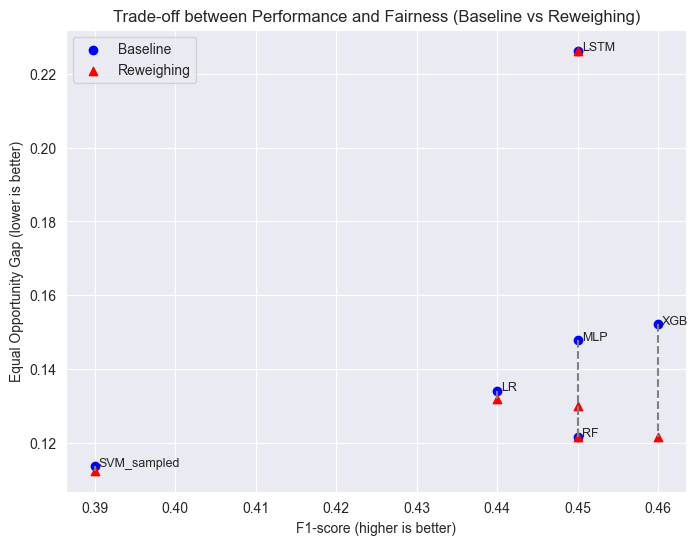

In [1]:
import os
import matplotlib.pyplot as plt

# threshold_best F1-score and EO gap
models = ["LR", "RF", "XGB", "MLP", "LSTM", "SVM_sampled"]
baseline_f1 = [0.44, 0.45, 0.46, 0.45, 0.45, 0.39]
reweighing_f1 = [0.44, 0.45, 0.46, 0.45, 0.45, 0.39]

baseline_eo = [0.1342, 0.1217, 0.1521, 0.1478, 0.2262, 0.1138]
reweighing_eo = [0.1318, 0.1301, 0.1217, 0.1216, 0.2262, 0.1125]

plt.figure(figsize=(8,6))
for i, model in enumerate(models):
    # baseline
    plt.scatter(baseline_f1[i], baseline_eo[i], color="blue", marker="o", label="Baseline" if i==0 else "")
    # reweighing
    plt.scatter(reweighing_f1[i], reweighing_eo[i], color="red", marker="^", label="Reweighing" if i==0 else "")
    # connect baseline and reweighing
    plt.plot([baseline_f1[i], reweighing_f1[i]], [baseline_eo[i], reweighing_eo[i]], color="gray", linestyle="--")
    # annotate model name
    plt.text(baseline_f1[i]+0.0005, baseline_eo[i], model, fontsize=9)

plt.xlabel("F1-score (higher is better)")
plt.ylabel("Equal Opportunity Gap (lower is better)")
plt.legend()
plt.title("Trade-off between Performance and Fairness (Baseline vs Reweighing)")

# Save the figure
save_path = "pictures/baseline_vs_reweighed"
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path, "tradeoff_f1_eo.png"), dpi=300, bbox_inches="tight")

print(f"Figure saved to {save_path}")

plt.show()
plt.close()


In [15]:
import os
import matplotlib.pyplot as plt

# three methods of MLP (best threshold)
methods = ["Baseline", "Reweighing", "Adversarial"]
f1_scores = [0.45, 0.45, 0.444]   # F1-score
eo_gaps = [0.1478, 0.1216, 0.0989] # addr_state EO gap

plt.figure(figsize=(7,6))
plt.scatter(eo_gaps[0], f1_scores[0], color="blue", marker="o", label="Baseline")
plt.scatter(eo_gaps[1], f1_scores[1], color="red", marker="^", label="Reweighing")
plt.scatter(eo_gaps[2], f1_scores[2], color="green", marker="s", label="Adversarial")

plt.plot(eo_gaps, f1_scores, color="gray", linestyle="--")

for i, method in enumerate(methods):
    plt.text(eo_gaps[i] + 0.002, f1_scores[i], method, fontsize=9)

plt.xlabel("Equal Opportunity Gap (lower is better)")
plt.ylabel("F1-score (higher is better)")
plt.title("Trade-off in MLP: Baseline vs Reweighing vs Adversarial")
plt.legend()

save_path = "pictures/mlp_all_methods"
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path, "mlp_menthods.png"), dpi=300, bbox_inches="tight")
plt.close()
